# 🏦 Stock Price Predictions

This project analyzes 5 stock prices over time to build predictive models that can help inform financial market decisions, stock allocations and more. This is done by applying 3 distinct modelling paradigms: time-series forecasting, survival analysis, and ranking.

## 0. Project Overview

**Analyzing historical data in 16 years of stock market data to predict stock price movements of five major tech firms** in the U.S.: Apple, Microsoft, Amazon, Google, and Meta. 

- Included stocks: 
    1. Apple (AAPL), 
    2. Microsoft (MSFT), 
    3. Amazon (AMZN), 
    4. Google (GOOGL), 
    5. Meta (META)

- 🗓️ Temporal Coverage: 2010 to 2026
    - All trading days between January 1, 2010 to March 20, 2026

- Data: Yahoo Finance `yfinance` API


### 🎯 Objectives:
1. **Time-series forecasting** to predict future asset behavior
    - Test different types of forecasting models
    - Forecast next month's stock prices for all 5 equities
2. **Survival Analysis** to model the time until significant price movement occurs.
    - Determine amount of days until ≥5% daily increase in stock price
3. **Asset Ranking** to list which assets to prioritize
    - Rank the 5 stocks according to possible daily gains

### Key Findings:

### Importing

In [140]:
from helper import *
from functools import partial
import warnings
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
%matplotlib inline
import warnings
from scipy import stats
from itertools import combinations
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import lightgbm as lgb
from lightgbm import LGBMRegressor
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from itertools import combinations
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ndcg_score


sns.set_style("darkgrid")
sns.set_theme(
    "notebook",
    rc={
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    },
)
sns.set_palette(["green"])

📌 The end date of this project will have a cut-off for consistent and repeatable results to be able to observe model performance over a fixed date.

**Cut-off date: March 21, 2026**

In [141]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
start_date = "2010-01-01"
end_date = "2026-03-21"

In [142]:
df_import = yf.download(
    tickers, start=start_date, end=end_date, interval="1d", auto_adjust=True
)
# df_import.to_csv("dataset/stock_data.csv")
df = df_import.copy()
df.head()

[                       0%                       ]

[*********************100%***********************]  5 of 5 completed


Price          Close                                         High          \
Ticker          AAPL    AMZN      GOOGL META       MSFT      AAPL    AMZN   
Date                                                                        
2010-01-04  6.412384  6.6950  15.555865  NaN  23.077387  6.427066  6.8305   
2010-01-05  6.423470  6.7345  15.487362  NaN  23.084839  6.459725  6.7740   
2010-01-06  6.321297  6.6125  15.096947  NaN  22.943167  6.448939  6.7365   
2010-01-07  6.309610  6.5000  14.745496  NaN  22.704571  6.352158  6.6160   
2010-01-08  6.351558  6.6760  14.942071  NaN  22.861145  6.352158  6.6840   

Price                                  ...      Open                          \
Ticker          GOOGL META       MSFT  ...      AAPL    AMZN      GOOGL META   
Date                                   ...                                     
2010-01-04  15.624369  NaN  23.189232  ...  6.395005  6.8125  15.560829  NaN   
2010-01-05  15.582919  NaN  23.189229  ...  6.430062  6.6715  15.566538  NaN   
2010-01-06  15.533777  NaN  23.174313  ...  6.423470  6.7300  15.533777  NaN   
2010-01-07  15.140133  NaN  22.890979  ...  6.344667  6.6005  15.125240  NaN   
2010-01-08  14.972598  NaN  23.025184  ...  6.301220  6.5280  14.693375  NaN   

Price                     Volume                                       
Ticker           MSFT       AAPL       AMZN      GOOGL META      MSFT  
Date                                                                   
2010-01-04  22.831328  493729600  151998000   78169752  NaN  38409100  
2010-01-05  23.002820  601904800  177038000  120067812  NaN  49749600  
2010-01-06  23.025186  552160000  143576000  158988852  NaN  58182400  
2010-01-07  22.838784  477131200  220604000  256315428  NaN  50559700  
2010-01-08  22.577805  447610800  196610000  188783028  NaN  51197400  

[5 rows x 25 columns]

## 1. Data Cleaning

In [143]:
df.shape

(4078, 25)

Working with 4,078 points of data, meaning **4,078 trading days**.

### Data Types

For time series forecasting and other financial modelling processes, it is best if our **Index is in datetime format.**

In [144]:
print("Index data type: ", df.index.dtype)
print("Other Data Types: \n", df.dtypes)

Index data type:  datetime64[ns]
Other Data Types: 
 Price   Ticker
Close   AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
High    AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Low     AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Open    AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Volume  AAPL        int64
        AMZN        int64
        GOOGL       int64
        META      float64
        MSFT        int64
dtype: object


Minor fix: Uniform all Volume int features to float

In [145]:
df = df.astype(float)
df["Volume"].dtypes

Ticker
AAPL     float64
AMZN     float64
GOOGL    float64
META     float64
MSFT     float64
dtype: object

#### Null Values & Duplicates

In [146]:
df.isna().sum()

Price   Ticker
Close   AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
High    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Low     AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Open    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Volume  AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
dtype: int64

In [147]:
df["Volume"]["META"].first_valid_index()

Timestamp('2012-05-18 00:00:00')

The null values stem from Meta stocks beginning ~2 years later, missing 599 trading days. Meta went public on the stock market with its Initial Public Offering (IPO) on May 18, 2012. During modelling, the nulls will be dropped.

In [148]:
df.duplicated().sum()

np.int64(0)

There are no duplicates present.

### 🔧 Feature Engineering

Adding 2 additional informational features:
1. Daily Returns (Log): analyzing percentage log change return of stocks in a day
2. Monthly Volatility: Measure of uncertainty about the returns provided by the stock. Rolled over 21 days and annualized.

In [149]:
log_ret = np.log(df["Close"] / df["Close"].shift(1))
log_ret.columns = pd.MultiIndex.from_product([["Return"], log_ret.columns])

# monthly volatility 21 day rolling annualized
monthly_vol = log_ret["Return"].rolling(21).std() * np.sqrt(252)
monthly_vol.columns = pd.MultiIndex.from_product([["Volatility"], monthly_vol.columns])

df = pd.concat([df, log_ret, monthly_vol], axis=1)
df.tail()

Close                                                  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT   
Date                                                                     
2026-03-16  252.820007  211.740005  305.559998  627.450012  399.950012   
2026-03-17  254.229996  215.199997  310.920013  622.659973  399.410004   
2026-03-18  249.940002  209.869995  307.690002  615.679993  391.790009   
2026-03-19  248.960007  208.759995  307.130005  606.700012  389.019989   
2026-03-20  247.990005  205.369995  301.000000  593.659973  381.869995   

                  High                                                  ...  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT  ...   
Date                                                                    ...   
2026-03-16  253.889999  212.720001  306.489990  634.750000  400.630005  ...   
2026-03-17  255.130005  215.699997  311.420013  636.549988  404.399994  ...   
2026-03-18  254.940002  215.139999  312.470001  622.650024  398.000000  ...   
2026-03-19  251.830002  209.119995  308.059998  613.000000  392.489990  ...   
2026-03-20  249.199997  207.539993  306.000000  603.960022  387.000000  ...   

              Return                                         Volatility  \
Ticker          AAPL      AMZN     GOOGL      META      MSFT       AAPL   
Date                                                                      
2026-03-16  0.010737  0.019409  0.010792  0.022997  0.011062   0.248129   
2026-03-17  0.005562  0.016209  0.017390 -0.007663 -0.001351   0.236627   
2026-03-18 -0.017018 -0.025080 -0.010443 -0.011273 -0.019262   0.213657   
2026-03-19 -0.003929 -0.005303 -0.001822 -0.014693 -0.007095   0.213103   
2026-03-20 -0.003904 -0.016372 -0.020161 -0.021728 -0.018551   0.209027   

                                                    
Ticker          AMZN     GOOGL      META      MSFT  
Date                                                
2026-03-16  0.255326  0.229118  0.275346  0.221319  
2026-03-17  0.258090  0.233990  0.271637  0.221323  
2026-03-18  0.274727  0.232849  0.273830  0.228083  
2026-03-19  0.269510  0.232689  0.275773  0.227519  
2026-03-20  0.276096  0.243558  0.282677  0.235315  

[5 rows x 35 columns]

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4078 entries, 2010-01-04 to 2026-03-20
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, AAPL)        4078 non-null   float64
 1   (Close, AMZN)        4078 non-null   float64
 2   (Close, GOOGL)       4078 non-null   float64
 3   (Close, META)        3479 non-null   float64
 4   (Close, MSFT)        4078 non-null   float64
 5   (High, AAPL)         4078 non-null   float64
 6   (High, AMZN)         4078 non-null   float64
 7   (High, GOOGL)        4078 non-null   float64
 8   (High, META)         3479 non-null   float64
 9   (High, MSFT)         4078 non-null   float64
 10  (Low, AAPL)          4078 non-null   float64
 11  (Low, AMZN)          4078 non-null   float64
 12  (Low, GOOGL)         4078 non-null   float64
 13  (Low, META)          3479 non-null   float64
 14  (Low, MSFT)          4078 non-null   float64
 15  (Open, AAPL)        

### 🔎 Findings
- 4,078 trading day rows of data
- META contains 599 null data, appearing 2 years later than the other 4 trading stocks. 
- 2 new features:
    - Log Returns
    - Volatility (21d)

## 📊 2. Exploratory Data Analysis

In [151]:
df.head()

Close                                         High          \
Ticker          AAPL    AMZN      GOOGL META       MSFT      AAPL    AMZN   
Date                                                                        
2010-01-04  6.412384  6.6950  15.555865  NaN  23.077387  6.427066  6.8305   
2010-01-05  6.423470  6.7345  15.487362  NaN  23.084839  6.459725  6.7740   
2010-01-06  6.321297  6.6125  15.096947  NaN  22.943167  6.448939  6.7365   
2010-01-07  6.309610  6.5000  14.745496  NaN  22.704571  6.352158  6.6160   
2010-01-08  6.351558  6.6760  14.942071  NaN  22.861145  6.352158  6.6840   

                                       ...    Return                           \
Ticker          GOOGL META       MSFT  ...      AAPL      AMZN     GOOGL META   
Date                                   ...                                      
2010-01-04  15.624369  NaN  23.189232  ...       NaN       NaN       NaN  NaN   
2010-01-05  15.582919  NaN  23.189229  ...  0.001727  0.005883 -0.004413  NaN   
2010-01-06  15.533777  NaN  23.174313  ... -0.016034 -0.018282 -0.025532  NaN   
2010-01-07  15.140133  NaN  22.890979  ... -0.001850 -0.017160 -0.023555  NaN   
2010-01-08  14.972598  NaN  23.025184  ...  0.006626  0.026717  0.013243  NaN   

                     Volatility                       
Ticker          MSFT       AAPL AMZN GOOGL META MSFT  
Date                                                  
2010-01-04       NaN        NaN  NaN   NaN  NaN  NaN  
2010-01-05  0.000323        NaN  NaN   NaN  NaN  NaN  
2010-01-06 -0.006156        NaN  NaN   NaN  NaN  NaN  
2010-01-07 -0.010454        NaN  NaN   NaN  NaN  NaN  
2010-01-08  0.006872        NaN  NaN   NaN  NaN  NaN  

[5 rows x 35 columns]

In [152]:
df.tail()

Close                                                  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT   
Date                                                                     
2026-03-16  252.820007  211.740005  305.559998  627.450012  399.950012   
2026-03-17  254.229996  215.199997  310.920013  622.659973  399.410004   
2026-03-18  249.940002  209.869995  307.690002  615.679993  391.790009   
2026-03-19  248.960007  208.759995  307.130005  606.700012  389.019989   
2026-03-20  247.990005  205.369995  301.000000  593.659973  381.869995   

                  High                                                  ...  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT  ...   
Date                                                                    ...   
2026-03-16  253.889999  212.720001  306.489990  634.750000  400.630005  ...   
2026-03-17  255.130005  215.699997  311.420013  636.549988  404.399994  ...   
2026-03-18  254.940002  215.139999  312.470001  622.650024  398.000000  ...   
2026-03-19  251.830002  209.119995  308.059998  613.000000  392.489990  ...   
2026-03-20  249.199997  207.539993  306.000000  603.960022  387.000000  ...   

              Return                                         Volatility  \
Ticker          AAPL      AMZN     GOOGL      META      MSFT       AAPL   
Date                                                                      
2026-03-16  0.010737  0.019409  0.010792  0.022997  0.011062   0.248129   
2026-03-17  0.005562  0.016209  0.017390 -0.007663 -0.001351   0.236627   
2026-03-18 -0.017018 -0.025080 -0.010443 -0.011273 -0.019262   0.213657   
2026-03-19 -0.003929 -0.005303 -0.001822 -0.014693 -0.007095   0.213103   
2026-03-20 -0.003904 -0.016372 -0.020161 -0.021728 -0.018551   0.209027   

                                                    
Ticker          AMZN     GOOGL      META      MSFT  
Date                                                
2026-03-16  0.255326  0.229118  0.275346  0.221319  
2026-03-17  0.258090  0.233990  0.271637  0.221323  
2026-03-18  0.274727  0.232849  0.273830  0.228083  
2026-03-19  0.269510  0.232689  0.275773  0.227519  
2026-03-20  0.276096  0.243558  0.282677  0.235315  

[5 rows x 35 columns]

#### 🔎 Features:
- Date - trading day
- Ticker - Stock label of the equity

7 features per Date & Ticker:
- Close - close price of the day
- High - maximum price during the day
- Low - lowest price during the day
- Open - first trade price
- Volume - the total number of shares or contracts exchanged in a market within the single trading day
- Return (Log) - Daily return in log
- Volatility (over 21 days) - rolling return volatility over 21 days


In [153]:
df.describe().T

count          mean           std           min  \
           Ticker                                                     
Close      AAPL    4078.0  7.987326e+01  7.737868e+01  5.754396e+00   
           AMZN    4078.0  8.240227e+01  7.049640e+01  5.430500e+00   
           GOOGL   4078.0  7.350043e+01  6.517423e+01  1.082321e+01   
           META    3479.0  2.262066e+02  1.845031e+02  1.759195e+01   
           MSFT    4078.0  1.529355e+02  1.475922e+02  1.731506e+01   
High       AAPL    4078.0  8.066842e+01  7.814116e+01  5.872749e+00   
           AMZN    4078.0  8.335468e+01  7.131071e+01  5.564500e+00   
           GOOGL   4078.0  7.426560e+01  6.592371e+01  1.097734e+01   
           META    3479.0  2.290491e+02  1.867900e+02  1.812774e+01   
           MSFT    4078.0  1.543281e+02  1.488775e+02  1.754833e+01   
Low        AAPL    4078.0  7.901003e+01  7.655133e+01  5.700463e+00   
           AMZN    4078.0  8.139622e+01  6.965596e+01  5.290000e+00   
           GOOGL   4078.0  7.268502e+01  6.434950e+01  1.076265e+01   
           META    3479.0  2.232798e+02  1.822268e+02  1.741335e+01   
           MSFT    4078.0  1.514174e+02  1.462190e+02  1.710436e+01   
Open       AAPL    4078.0  7.981369e+01  7.731344e+01  5.763984e+00   
           AMZN    4078.0  8.242136e+01  7.053147e+01  5.296500e+00   
           GOOGL   4078.0  7.346815e+01  6.513312e+01  1.087881e+01   
           META    3479.0  2.261933e+02  1.846577e+02  1.793922e+01   
           MSFT    4078.0  1.529136e+02  1.476142e+02  1.737526e+01   
Volume     AAPL    4078.0  2.167471e+08  2.149447e+08  1.791060e+07   
           AMZN    4078.0  8.042141e+07  5.099916e+07  1.142050e+07   
           GOOGL   4078.0  5.466198e+07  4.619297e+07  9.312000e+06   
           META    3479.0  2.812559e+07  2.506408e+07  4.726100e+06   
           MSFT    4078.0  3.530910e+07  2.053455e+07  5.855900e+06   
Return     AAPL    4077.0  8.965311e-04  1.771681e-02 -1.377082e-01   
           AMZN    4077.0  8.396988e-04  2.061634e-02 -1.513979e-01   
           GOOGL   4077.0  7.266795e-04  1.734130e-02 -1.236845e-01   
           META    3478.0  7.908289e-04  2.499121e-02 -3.063905e-01   
           MSFT    4077.0  6.883068e-04  1.614319e-02 -1.594532e-01   
Volatility AAPL    4057.0  2.578091e-01  1.141445e-01  7.239734e-02   
           AMZN    4057.0  3.041291e-01  1.250059e-01  7.747502e-02   
           GOOGL   4057.0  2.548794e-01  1.070830e-01  6.437360e-02   
           META    3458.0  3.499657e-01  1.829643e-01  6.973876e-02   
           MSFT    4057.0  2.344921e-01  1.084262e-01  5.474714e-02   

                            25%           50%           75%           max  
           Ticker                                                          
Close      AAPL    1.840808e+01  3.964087e+01  1.451946e+02  2.859225e+02  
           AMZN    1.557475e+01  6.985250e+01  1.458675e+02  2.540000e+02  
           GOOGL   2.626132e+01  5.205724e+01  1.129143e+02  3.434482e+02  
           META    9.626953e+01  1.727940e+02  2.954962e+02  7.881490e+02  
           MSFT    3.110652e+01  8.343568e+01  2.577983e+02  5.398252e+02  
High       AAPL    1.857221e+01  4.013305e+01  1.462209e+02  2.883502e+02  
           AMZN    1.572713e+01  7.162850e+01  1.475750e+02  2.586000e+02  
           GOOGL   2.647667e+01  5.265481e+01  1.139705e+02  3.487545e+02  
           META    9.760901e+01  1.747486e+02  2.992516e+02  7.943844e+02  
           MSFT    3.126173e+01  8.464271e+01  2.598709e+02  5.522420e+02  
Low        AAPL    1.820132e+01  3.939870e+01  1.433490e+02  2.830352e+02  
           AMZN    1.535088e+01  6.801575e+01  1.439352e+02  2.529000e+02  
           GOOGL   2.603333e+01  5.144108e+01  1.112990e+02  3.372326e+02  
           META    9.463238e+01  1.705615e+02  2.907583e+02  7.789906e+02  
           MSFT    3.085197e+01  8.210385e+01  2.544035e+02  5.385306e+02  
Open       AAPL    1.843168e+01  3.976604e+01  1.449956e+02  2.859325e+02  
           AMZN    1.555

* Notable findings:
    * META & MSFT show the highest mean closing price ($226, $153 respectively)
    * META has highest volatility

### Date

In [154]:
start_date = df.index[0]
end_date = df.index[-1]
duration = end_date - start_date

print("Start Date:", start_date.date())
print("End Date:", end_date.date())
print("Amount of Trading Days:", df.shape[0])

Start Date: 2010-01-04
End Date: 2026-03-20
Amount of Trading Days: 4078


### OHLC Distributions

In [155]:
logo_palette = {
    "AAPL": "#E03A3E",
    "MSFT": "#7fba00",
    "AMZN": "#ff9900",
    "GOOGL": "#FCBD07",
    "META": "#0082fb",
}

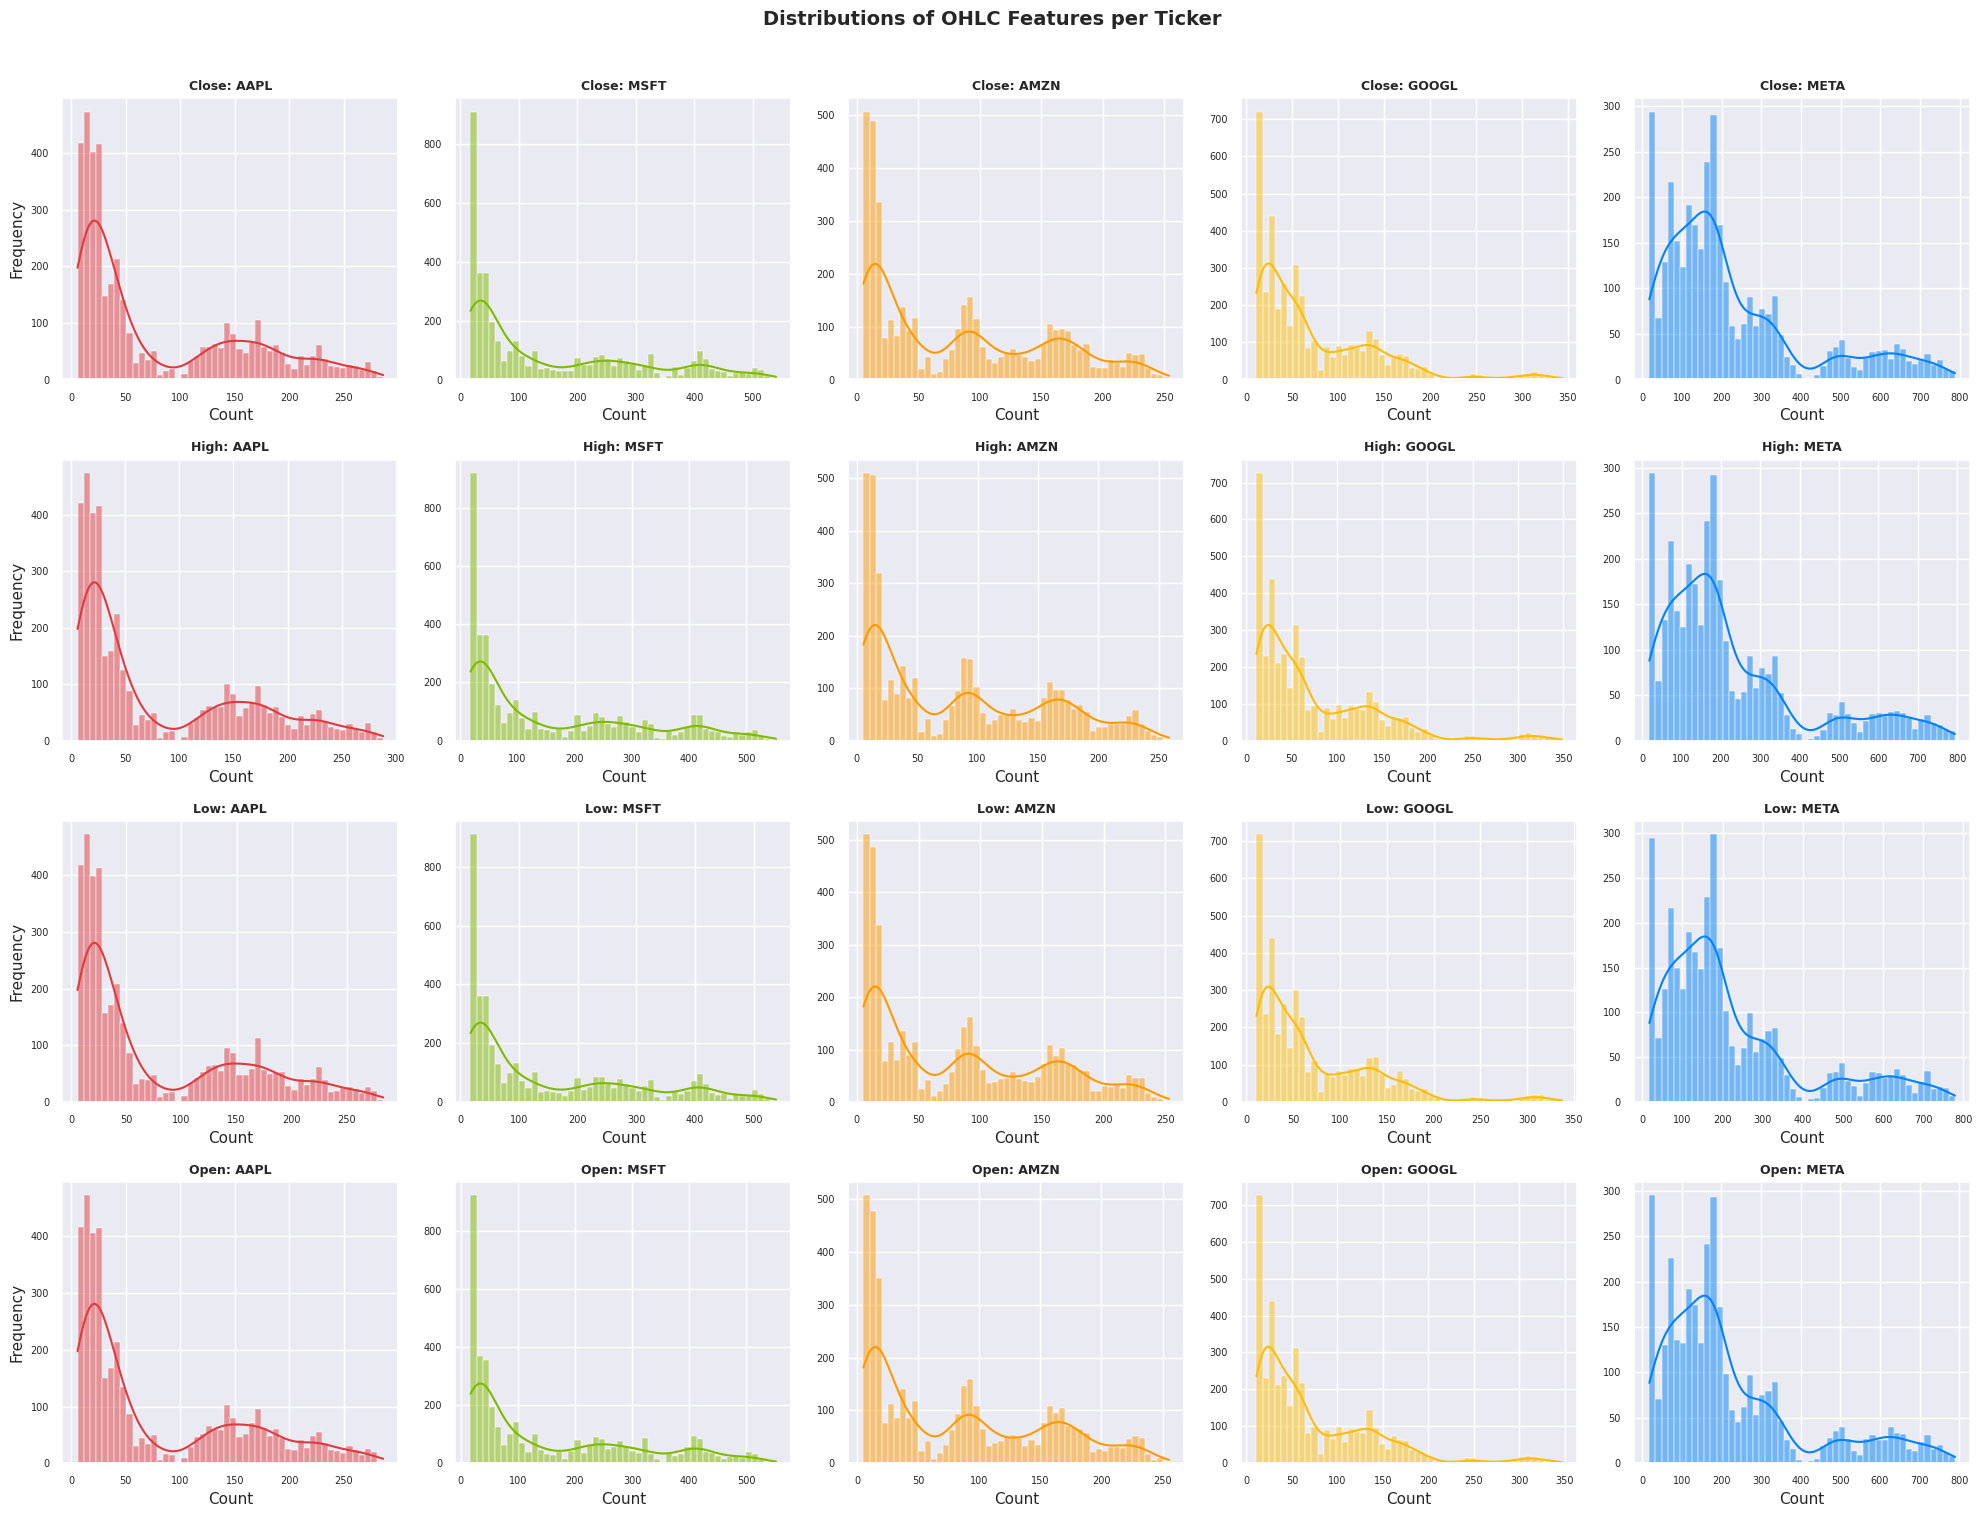

In [156]:
ohlc_cols = ["Close", "High", "Low", "Open"]

fig, axes = plt.subplots(len(ohlc_cols), len(tickers), figsize=(20, 15))

for i, feature in enumerate(ohlc_cols):
    for j, ticker in enumerate(tickers):
        ax = axes[i][j]
        sns.histplot(
            df[feature][ticker].dropna(),
            bins=50,
            ax=ax,
            kde=True,
            color=logo_palette[ticker],
        )
        ax.set_title(f"{feature}: {ticker}", fontsize=9)
        ax.set_xlabel("Count")
        ax.set_ylabel("Frequency" if j == 0 else "")
        ax.tick_params(labelsize=7)

plt.suptitle("Distributions of OHLC Features per Ticker", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

* Data is right tailed and positively skewed as expected for financial data, where most trading days cluster at lower price ranges and we can observe prices trending upward over time (early low prices and later high prices)
* AAPL, AMZN and META show secondary rises in their counts and KDE curves - suggests that these stocks went through different market regimes, growth phases, splits and more.

We will take a closer look at the Close Prices later on since it is the target variable to predict.

### Volume

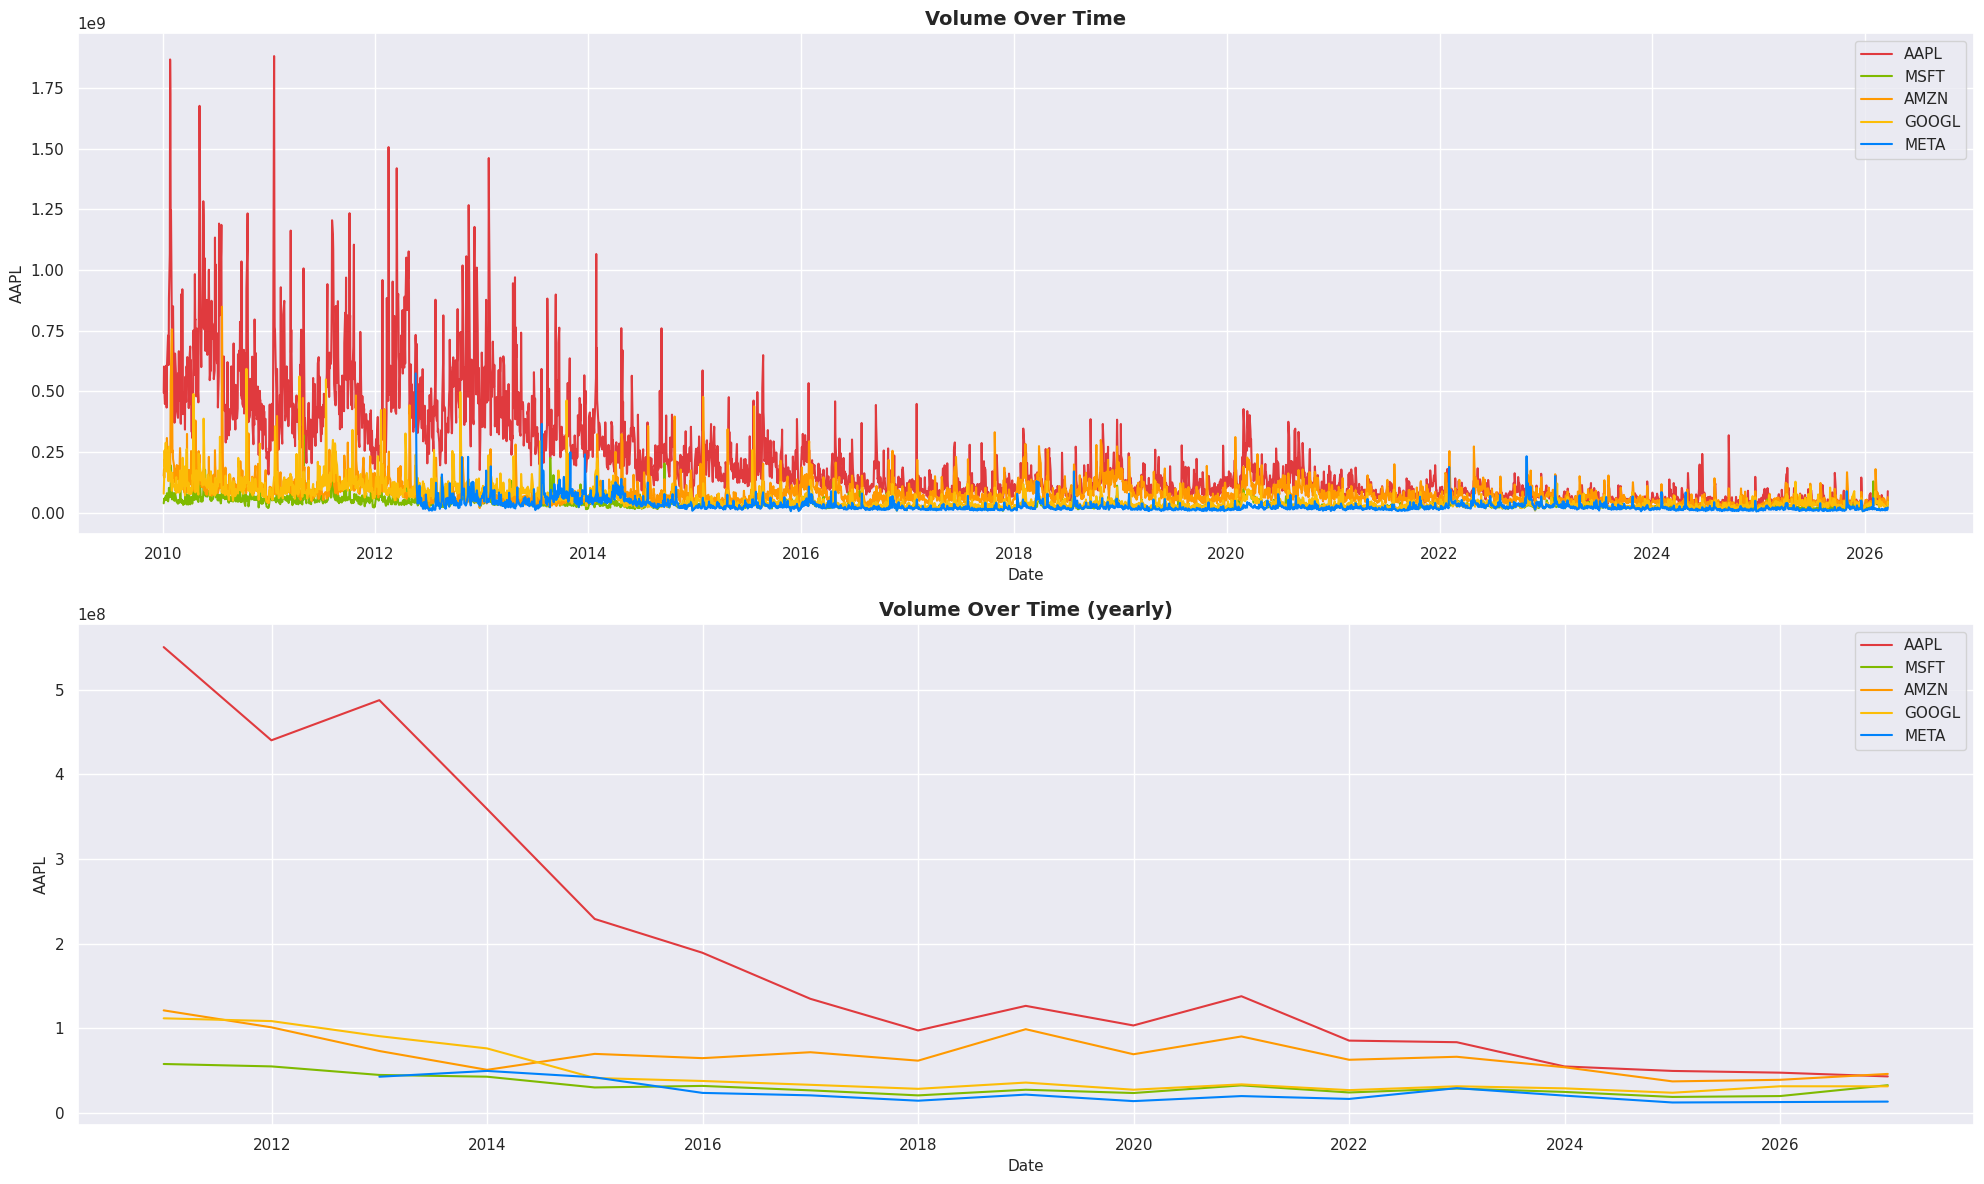

In [157]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

for ticker in tickers:
    sns.lineplot(
        data=df["Volume"],
        x=df.index,
        y=ticker,
        color=logo_palette[ticker],
        label=ticker,
        ax=axes[0],
    )
axes[0].set_title("Volume Over Time")
axes[0].tick_params(axis="x", rotation=0)

volume_yearly = df["Volume"].resample("YE").median()[tickers]
for ticker in tickers:
    sns.lineplot(
        data=volume_yearly,
        x=volume_yearly.index,
        y=ticker,
        color=logo_palette[ticker],
        label=ticker,
        ax=axes[1],
    )
axes[1].set_title("Volume Over Time (yearly)")

plt.tight_layout()
plt.show()

* Apple comparatively had an exponential amount of stock volume compared to the other 4 in the early 2010s. Reflectively if we look back on those years, Apple was the biggest tech innovator that brought about the concept of smartphones as a whole to the world, possibly explaining the large amount of shares in this period.
* In recent years Amazon follows closely with 2nd largest amount of shares.
* META has the lowest amount of shares.

### Returns & Volatility

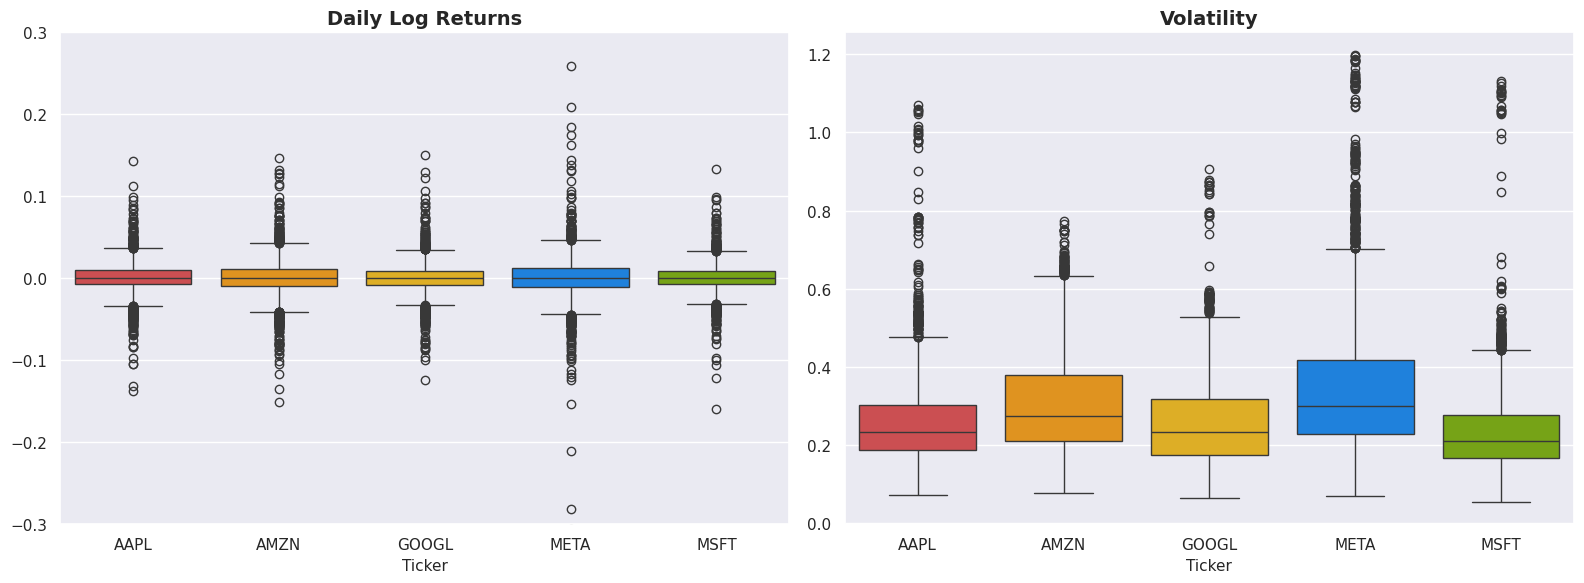

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df["Return"], palette=logo_palette, ax=axes[0])
axes[0].set_title("Daily Log Returns")
axes[0].set_ylim(-0.3, 0.3)

sns.boxplot(data=df["Volatility"], palette=logo_palette, ax=axes[1])
axes[1].set_title("Volatility")

plt.tight_layout()
plt.show()

* All assets except META stay within ±0.2 daily log returns.
* META has the largest expanse in returns and highest volatility.

#### Returns

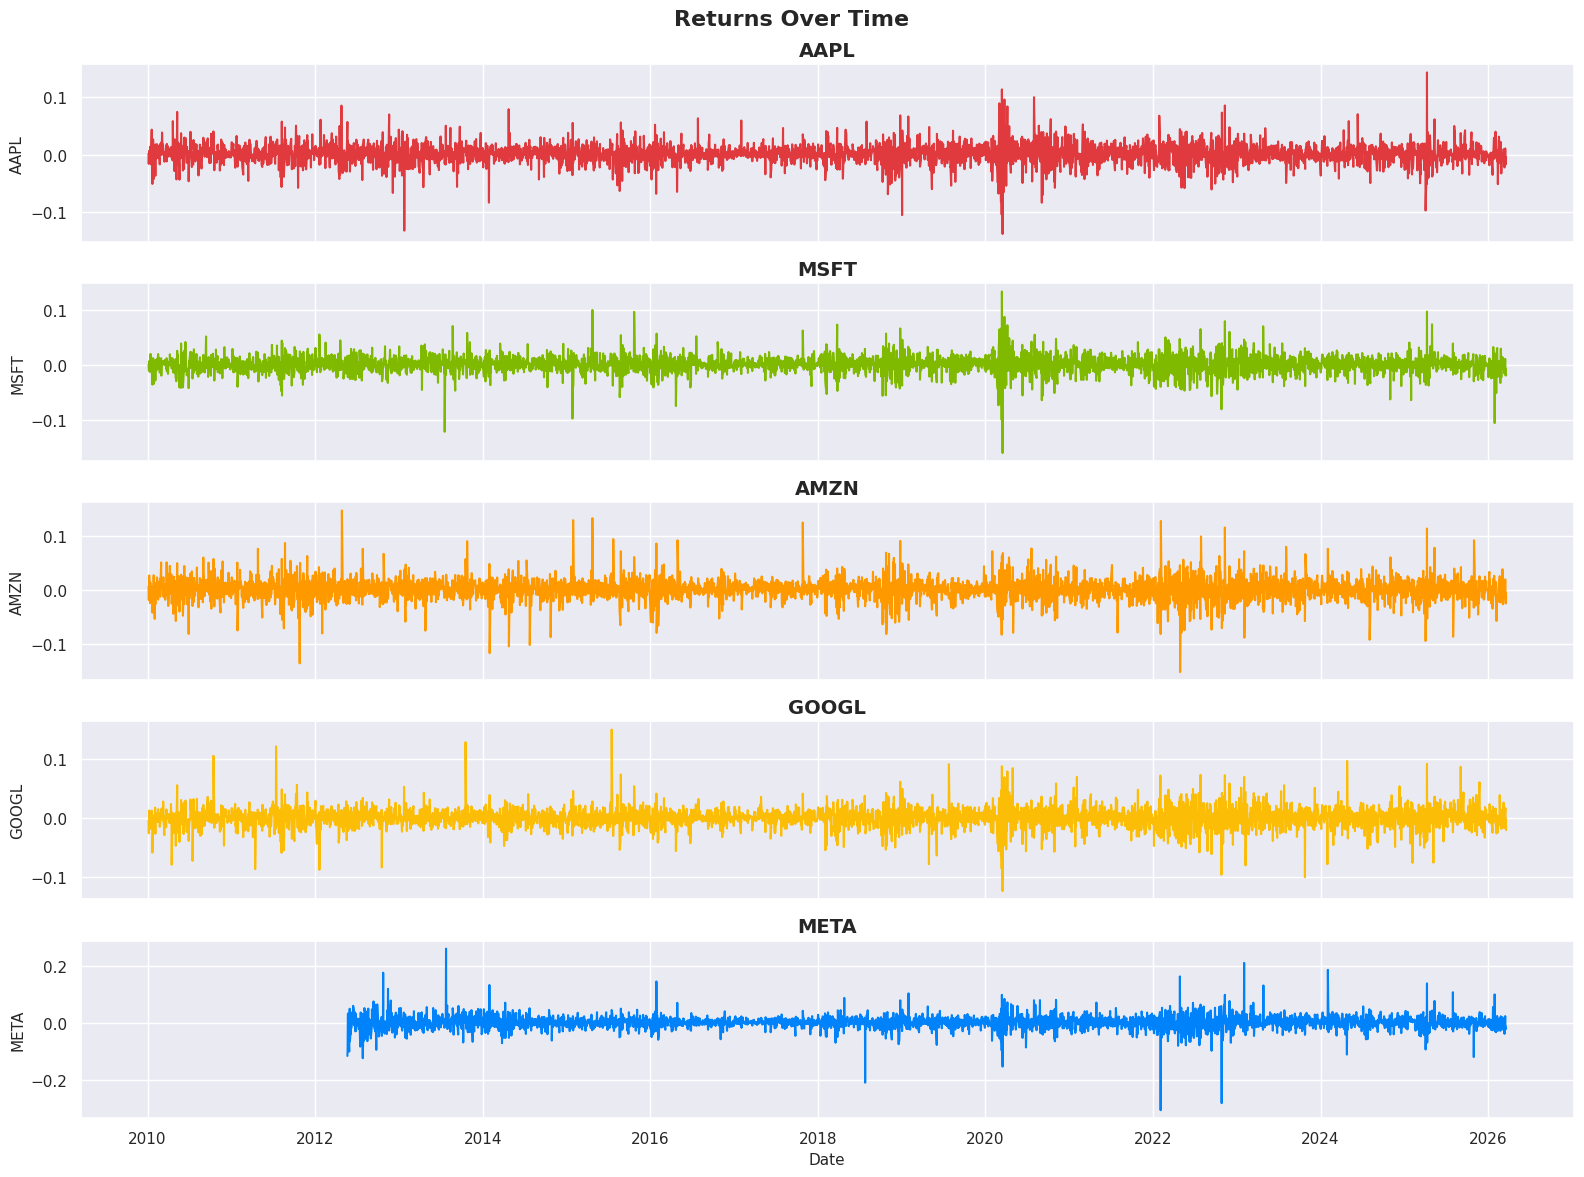

In [159]:
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for i, ticker in enumerate(tickers):
    sns.lineplot(data=df["Return"][ticker], ax=axes[i], color=logo_palette[ticker])
    axes[i].set_title(ticker)

plt.suptitle("Returns Over Time")
plt.tight_layout()
plt.show()

There are no clear intervals of spikes or drops or patterns visible here in daily returns over time between any of the assets.

#### Volatility

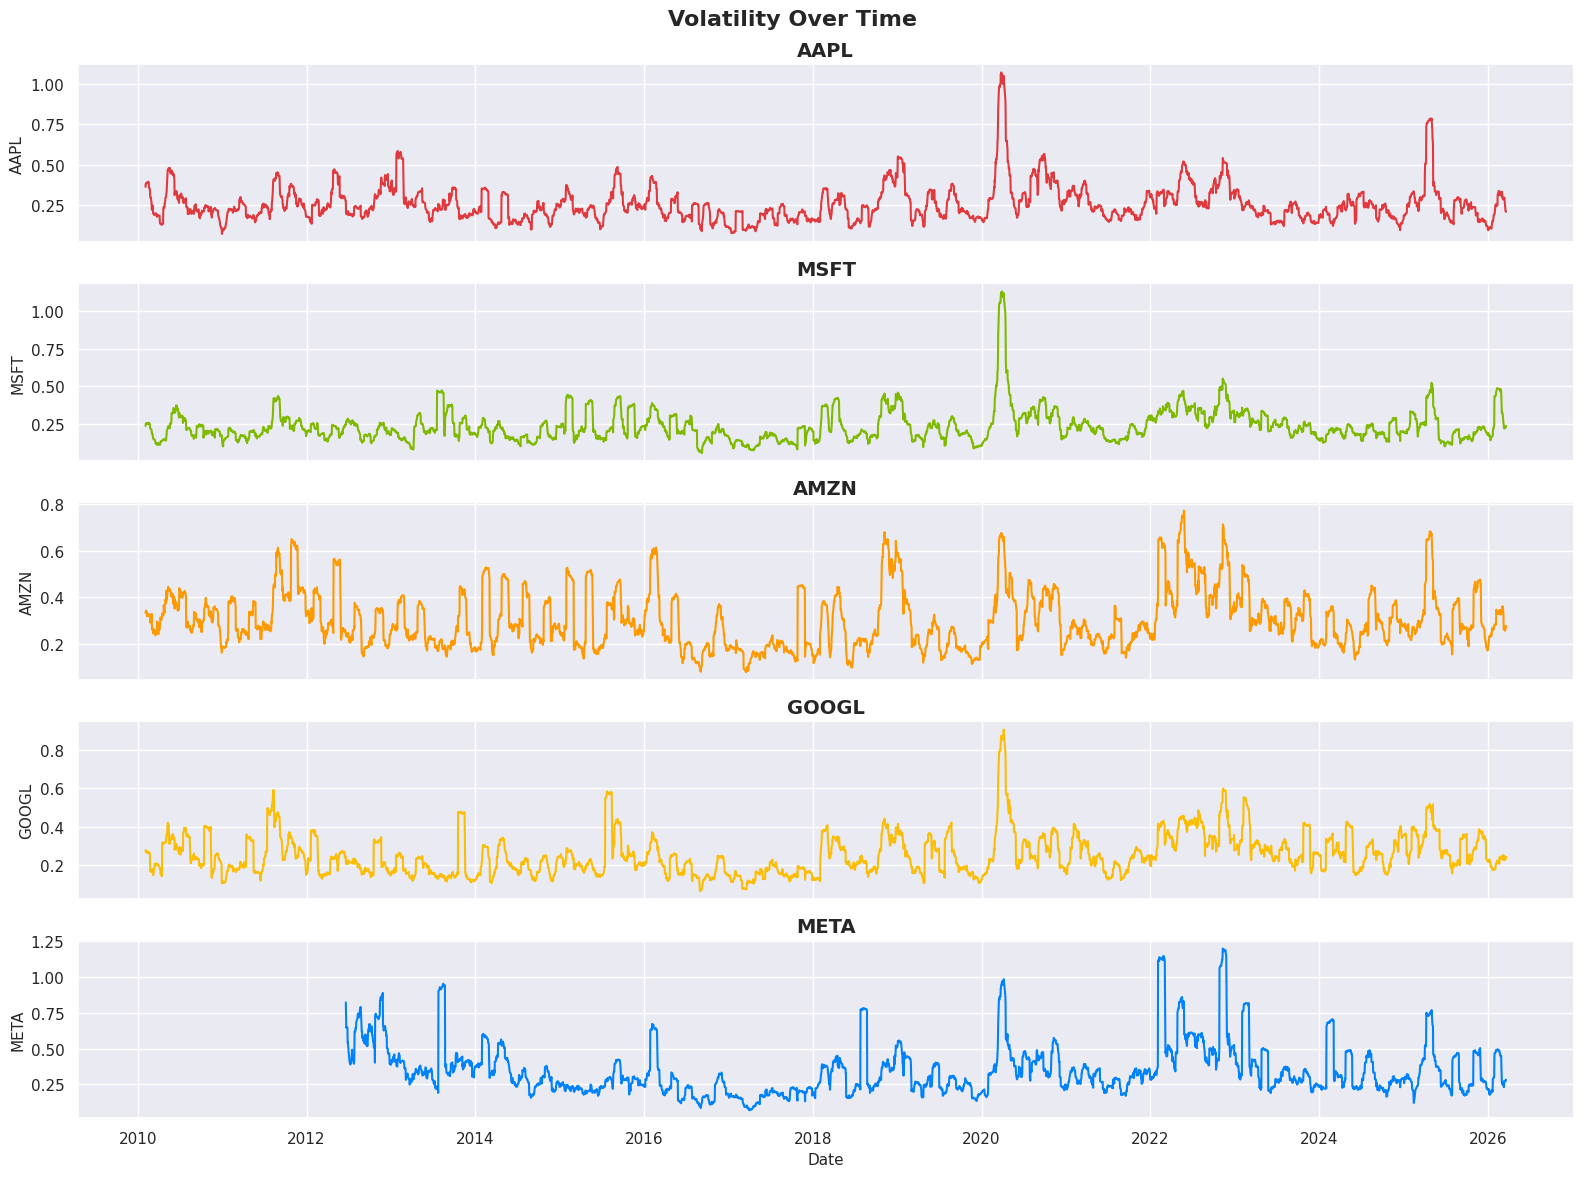

In [160]:
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for i, ticker in enumerate(tickers):
    sns.lineplot(data=df["Volatility"][ticker], ax=axes[i], color=logo_palette[ticker])
    axes[i].set_title(ticker)

plt.suptitle("Volatility Over Time")
plt.tight_layout()
plt.show()

* Clear volatility during the onset of the pandemic in 2020.
* META visibly has the most movement here as possibly the most volatile asset, next to AMZN. 

### Close Prices

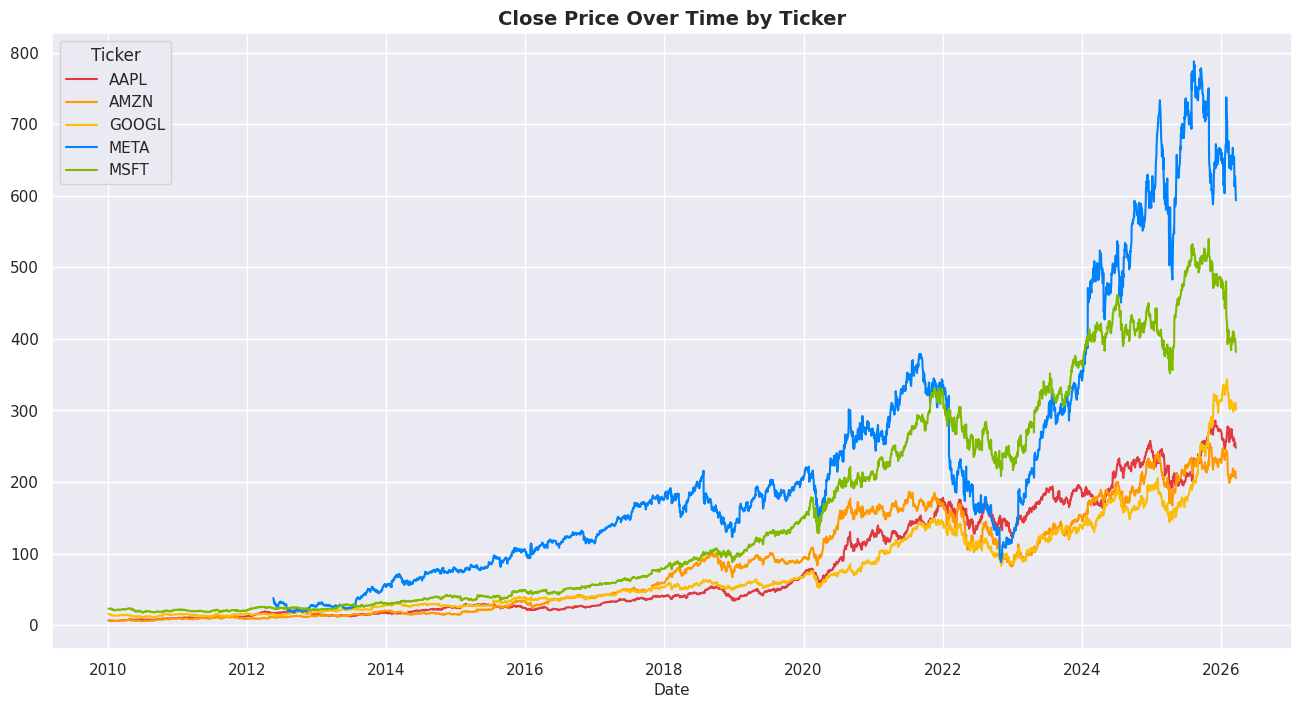

In [161]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=df["Close"], palette=logo_palette, dashes=False)
plt.title("Close Price Over Time by Ticker")
plt.show()

* Clear upward trend over the years reflecting the explosive growth of the tech industry. 
* META dominates Close prices with the highest values.
    * Sharp drop in 2022 but earns the most again in most recent years starting 2024.
* In this most recent year, prices are beginning to drop in 2026.

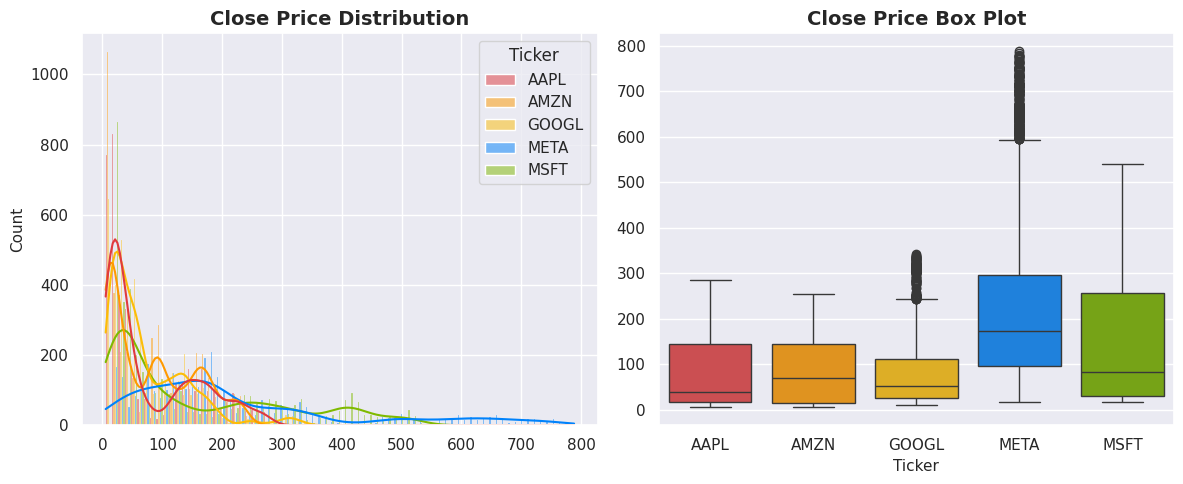

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=df["Close"], kde=True, palette=logo_palette, multiple="dodge", ax=axes[0]
)
axes[0].set_title("Close Price Distribution")

sns.boxplot(data=df["Close"], palette=logo_palette, ax=axes[1])
axes[1].set_title("Close Price Box Plot")

plt.tight_layout()
plt.show()

Again META has the highest close prices solely comprising the tail of the data, next to MSFT.

### Seasonal Decomposition

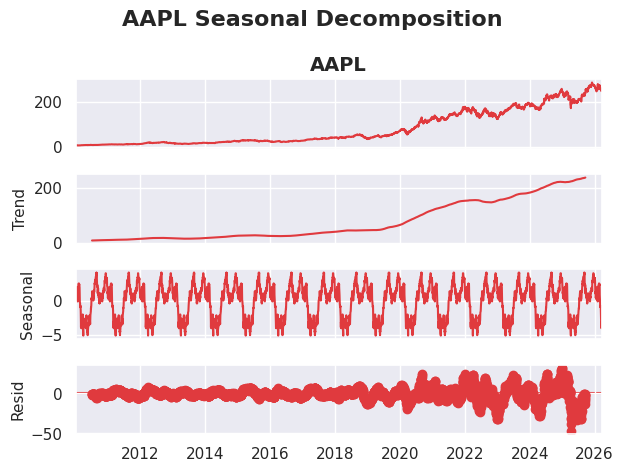

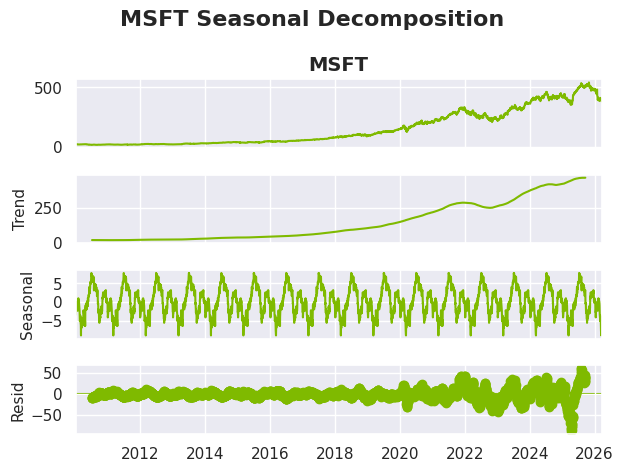

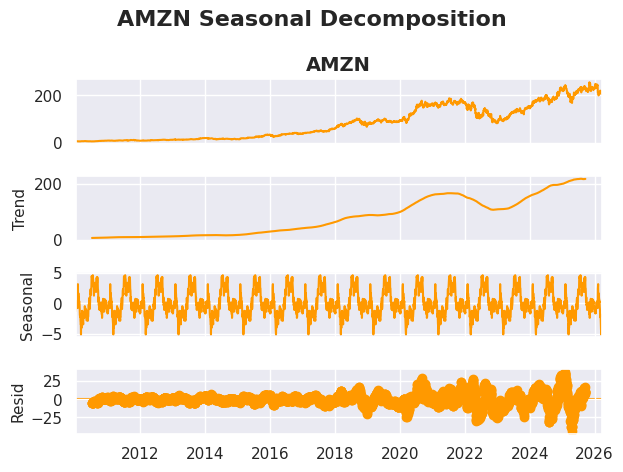

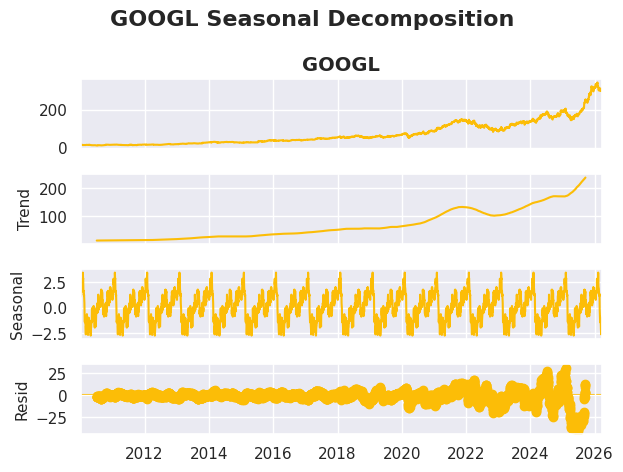

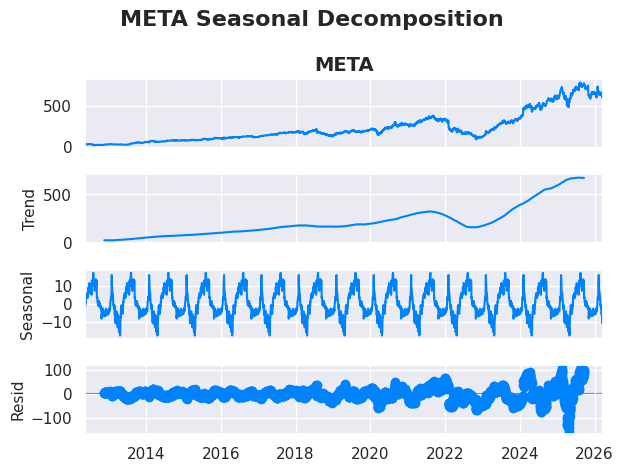

In [163]:
for ticker in tickers:
    series = df["Close"][ticker].dropna()
    decomposition = seasonal_decompose(series, model="additive", period=252)
    fig = decomposition.plot()
    for ax in fig.axes:
        for line in ax.get_lines():
            line.set_color(logo_palette[ticker])
    plt.suptitle(f"{ticker} Seasonal Decomposition")
    plt.tight_layout()
    plt.show()

Every asset displays the following:
* Trend: Clear long-term increasing trend in close prices as seen earlier
* Seasonal: Reveals recurring price patterns that repeat annually, possibly from quarterly earning, EOY or holiday cycles.
* Residuals: Dramatically increased residual fluctuations and volatility from 2020 onward.

⚠️ Trends need to be addressed for predictive modelling further on in this notebook.

### Correlations

#### Numerical Features Correlations

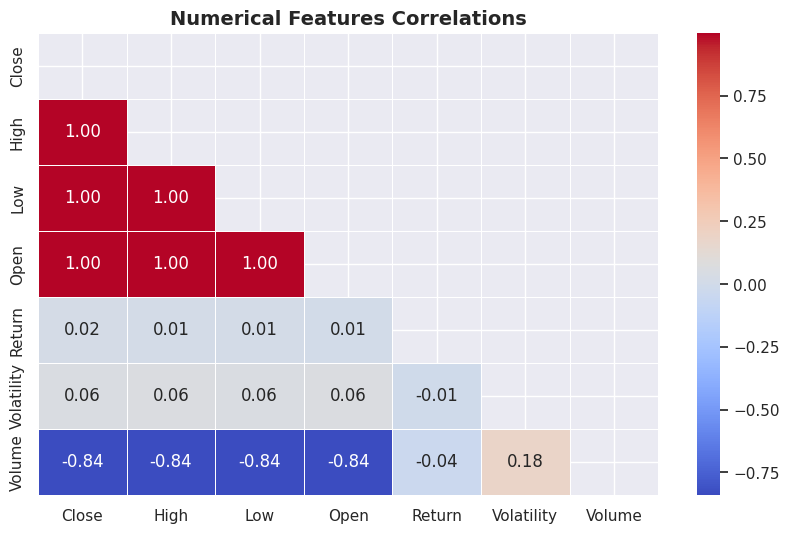

In [164]:
corr = df.T.groupby(level=0).mean().T.corr(method="spearman")
matrix = np.triu(corr)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, mask=matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Numerical Features Correlations")
plt.show()

* OHLC: These correlations are to be expected with OHLC essentially measuring the same underlying price of the trading day.
* Volume and Price (-0.84): With historical price data this is also to be expected, with more shares being traded at low prices. 

### Return Correlations

Do the 5 stocks move similarly when looking at daily returns?

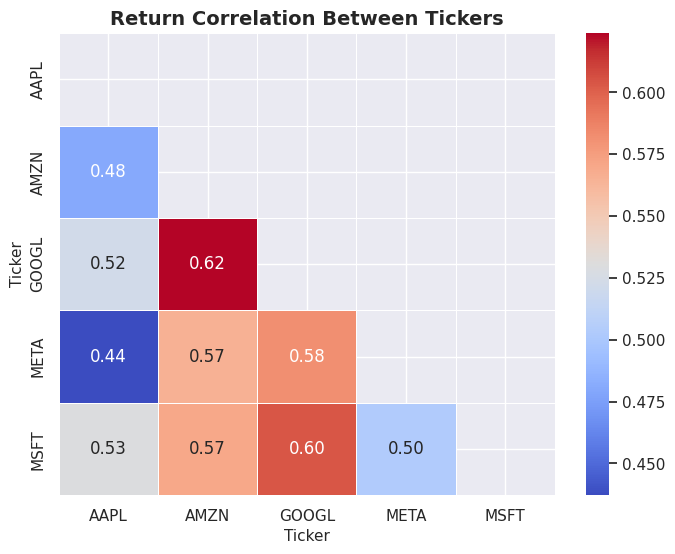

In [165]:
corr = df["Return"].corr(method="spearman")

matrix = np.triu(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Return Correlation Between Tickers")
plt.show()

Assets have moderate positive correlations ranging from *+0.44 to +0.62* suggesting that **returns between these 5 companies move in the same direction more often than not.**

### Key Findings in EDA:
- META has mostly shown the highest close prices and is the most volatile asset. 
- Second highest close prices comes from MSFT.
- **Upward increasing trends** across all equities.
- Stock returns between the 5 companies are moderately correlated which suggests similar movement.

## 3. Statistical Inference

> Perform statistical inference. This should include defining the target population, forming multiple statistical hypotheses and constructing confidence intervals, setting the significance levels, and conducting z or t-tests for these hypotheses.


**Target population:** Trading days

This dataset is populated with trading days with multiple stock pricing data for 5 assets.

### 3.1 Difference in Daily Returns

The correlation map above uncovered that all assets' returns have moderately positive correlation. We can test this further to see if their returns are statistically significantly different.

##### 🧪 Hypothesis:

* **H₀** (null hypothesis) - **Mean daily returns are not different between the assets**. 
* **Hₐ** (alternative hypothesis) - **Mean daily returns *do* differ significantly across the assets.**

* Significance level: **α=0.05**
    * Our significance threshold will be 0.05. 
    * P-values below this are statistically significant.

In [166]:
returns = df["Return"]
results = []

for t1, t2 in combinations(tickers, 2):
    aligned = returns[[t1, t2]].dropna()
    stat, p = stats.ttest_rel(aligned[t1], aligned[t2])
    results.append(
        {
            "Pair": f"{t1} vs {t2}",
            "t-stat": round(stat, 4),
            "p-value": round(p, 4),
            "Significant": p < 0.05,
        }
    )

pd.DataFrame(results)

,Pair,t-stat,p-value,Significant
0,AAPL vs MSFT,0.8462,0.3975,False
1,AAPL vs AMZN,0.1847,0.8535,False
2,AAPL vs GOOGL,0.6463,0.5181,False
3,AAPL vs META,-0.0021,0.9983,False
4,MSFT vs AMZN,-0.5504,0.5821,False
5,MSFT vs GOOGL,-0.1658,0.8683,False
6,MSFT vs META,0.0389,0.9689,False
7,AMZN vs GOOGL,0.4151,0.6781,False
8,AMZN vs META,0.1537,0.8779,False
9,GOOGL vs META,0.2000,0.8415,False


Conclusion: With all p-values > 0.05, the null hypothesis is rejected. Returns between all assets are different and **all returns move similarly.**

### 3.2 Ranking Inference 

Ranking the 5 stocks by which is most likely to give best returns. Ranking will also be modelled further on (see Chapter 6) and we may compare statistical results found here to modelling results in the later chapter. 

#### **Sharpe Ratio** 
The Sharpe Ratio will be used to rank which stocks are the most efficient according to return per unit of risk. 

This ratio is a measure of an investment's risk-adjusted performance, **defined by the difference between returns (mean returns) and the risk-free return (divided by the standard deviation of the returns)**

A **higher Sharpe ratio implies better returns for risk** taken while lower indicates worse returns or volatility.

#### Ranking Over All Historical Data:

In [167]:
sharpe_rank(df, time="overall")

,Ticker,Sharpe,CI_Low,CI_High,Rank
0,AAPL,0.8939,0.8564,0.9314,1
1,MSFT,0.8860,0.8486,0.9234,2
2,META,0.8159,0.7761,0.8558,3
3,AMZN,0.8087,0.7721,0.8452,4
4,GOOGL,0.7674,0.7313,0.8034,5


* Confidence Intervals: The confidence intervals never cross zero and are statistically significant to be within these 95% interval bounds.

* Ranking over time:
    * According to the Sharpe ratios where lower suggests better return-to-risk ratio, the stocks are ranked as follows over the past 16 years as follows:
        1. AAPL
        2. MSFT
        3. META
        4. AMZN
        5. GOOGL
    * All stocks have positive Sharpe ratios and returns.

#### Ranking Over Last Year

In [168]:
sharpe_rank(df, time="latest")

,Ticker,Sharpe,CI_Low,CI_High,Rank
0,GOOGL,2.0298,1.8138,2.2459,1
1,AAPL,0.4653,0.3353,0.5953,2
2,AMZN,0.1411,0.0169,0.2652,3
3,META,0.0506,-0.0730,0.1742,4
4,MSFT,-0.0299,-0.1534,0.0936,5


Over the past year, ranking is different as follows:
1. GOOGL - largest gap in Sharpe ratio with over 2 score gap
2. AAPL
3. AMZN
4. META
5. MSFT - negative performance

* The past year has bigger gaps between return-to-risk ratio, with GOOGL having a large gap from the others with a 2 Sharpe ratio
* Ratios over the last year are much smaller in measure (-0.02 to 0.46) in the recent market, compared to over-time historical ratios (0.76 to 0.89).

### Key Statistical Findings:
* Returns between the 5 stocks move similarly; the similarity is statistically significant.
* The market ranking predictions vary differently for the past year than compared to historical data. 

| Stock | Ranking (All Time) | Ranking (Last Year) |
|-------|------------------|---------------------|
| AAPL  | 1                | 2                   |
| MSFT  | 2                | 5                   |
| META  | 3                | 4                   |
| AMZN  | 4                | 3                   |
| GOOGL | 5                | 1                   |

## 📈 4. Time-Series Forecasting

> Build generic time-series model that is capable of predicting next day stock price based on previous patterns. Note: the model should be the same for all stocks. Evaluate its performance on each stock independently.

In this portion, forecasting models will be built to predict closing prices over the next month. Different models will be trialed to see which ones perform best on the data.


### 4.0 Data Preparation

Before forecasting, our time series data needs to have date as its Index which was already achieved. Second, data needs to be stationary.

Nulls that META has in its 2 years will be dropped but all historical data in the 4 other equities will be kept.

#### Stationarity
##### Checking for Stationarity

Using the ADF test we can observe if the data is stationary; a requirement for many time-series models like ARIMA. A p-value less than 0.05 will state that it is stationary.

In [169]:
df_close = df["Close"].copy()
for ticker in tickers:
    result = adfuller(df_close[ticker].dropna())
    print(f"{ticker} p-value: {result[1]:.4f}")

AAPL p-value: 0.9891
MSFT p-value: 0.9483
AMZN p-value: 0.9370
GOOGL p-value: 0.9986
META p-value: 0.9372


Data is **not stationary**, as expected of stock pricing and as observed earlier in multiple EDA plots. Differencing will be applied:

##### Differencing for Stationarity

In [170]:
df_diff = {}

for ticker in tickers:
    diff = df_close[ticker].diff().dropna()

    df_diff[ticker] = diff

    result = adfuller(diff)
    print(f"{ticker} diff p-value: {result[1]:.4f}")

AAPL diff p-value: 0.0000
MSFT diff p-value: 0.0000
AMZN diff p-value: 0.0000
GOOGL diff p-value: 0.0000
META diff p-value: 0.0000


✅ Significant p-values = 0. Data is now stationary for ARIMA modelling.

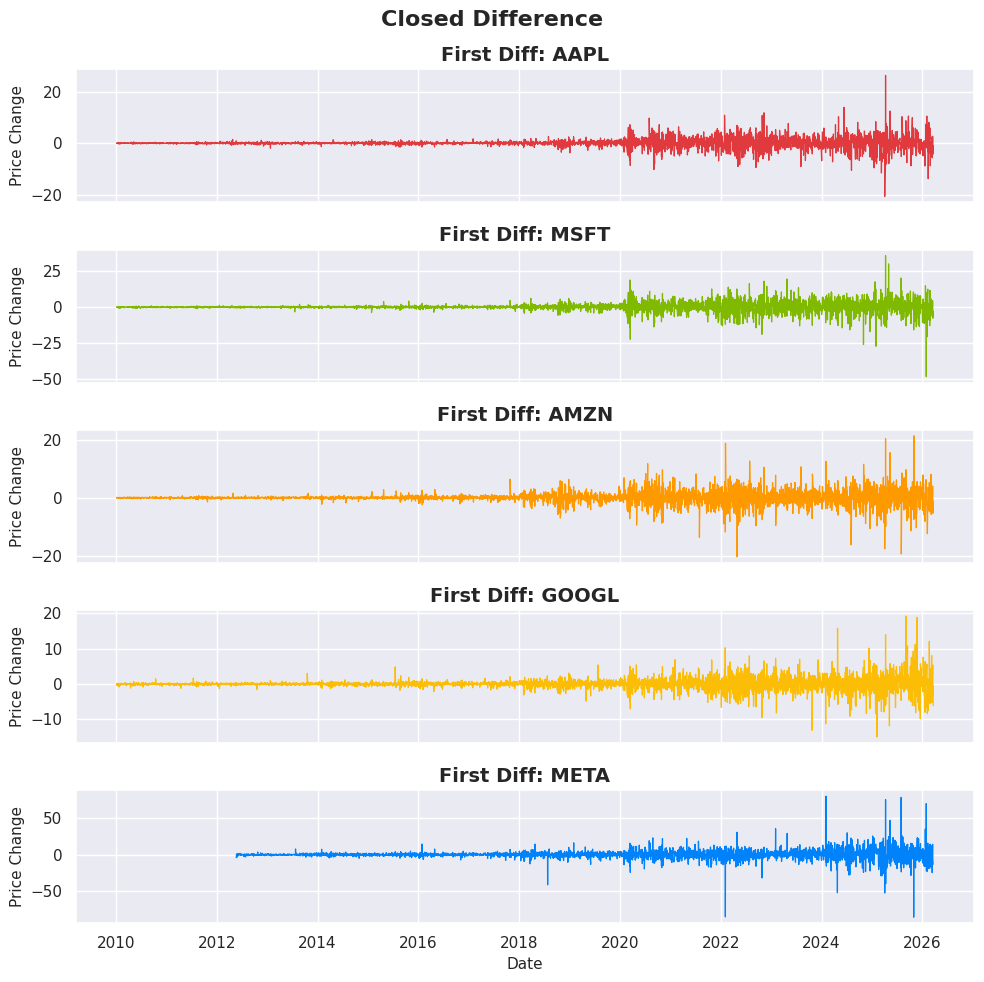

In [171]:
n = len(tickers)
fig, axes = plt.subplots(n, 1, figsize=(10, 2 * n), sharex=True)

for i, ticker in enumerate(tickers):
    sns.lineplot(
        x=df_diff[ticker].index,
        y=df_diff[ticker],
        ax=axes[i],
        linewidth=0.9,
        color=logo_palette[ticker],
    )
    axes[i].set_title(f"First Diff: {ticker}")
    axes[i].set_ylabel("Price Change")

plt.suptitle("Closed Difference")
plt.tight_layout()
plt.show()

Dropping nulls and aligning data

In [172]:
forecast_df = {}

for ticker in tickers:
    level_series = df_close[ticker].dropna()
    diff_series = level_series.diff().dropna()

    level_series = level_series.iloc[1:]

    forecast_df[ticker] = {
        "diff": diff_series.values,
        "level": level_series.values,
    }

### 4.1 Modelling

**Validation: Walk-Forward Validation**
* Models will be built and trained over specific time windows. 
* Training window is 1 trading year = 252 
* Test window is 1 trading month = 21

Overall this validation format helps for more realistic monthly reforecasting

**Model Types:**

This sprint introduced different types of forecasting models and such types will be explored here:
1. Simple Baseline Models - Moving Average
2. Exponential Smoothing Models - SES Model (Simple Exponential Smoothing)
3. ARIMA Models - ARIMA
4. Machine Learning Models - LightGBM

**Key Performance Metric: RMSE**
* RMSE will be our model performance metric of focus to view price prediction error while penalizing larger errors more heavily.
* MAE and MAPE will also be listed. Having MAPE (%) will allow for cross-asset comparability.

#### Baseline / Model 0: Moving Average (MA)
Averaging over a fixed window,  will be our baseline model. Calculating the average of past observations over a fixed window size (month) and uses this average as the prediction for the next time step. 

In [173]:
results = None

for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=ma_baseline_model,
        ticker=ticker,
        model_name="MA Baseline",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )

results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,MA Baseline,4.749604,4.023902,4.804368,0.014741
1,MSFT,MA Baseline,8.320841,7.149783,4.348838,-0.154662
2,AMZN,MA Baseline,6.646486,5.663413,6.044384,-0.211375
3,GOOGL,MA Baseline,4.625186,3.988639,4.991529,-0.083305
4,META,MA Baseline,17.705444,15.511416,6.355121,0.059474


In [174]:
results = None

for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=ma_baseline_model,
        ticker=ticker,
        model_name="MA Baseline",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )

results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,MA Baseline,4.749604,4.023902,4.804368,0.014741
1,MSFT,MA Baseline,8.320841,7.149783,4.348838,-0.154662
2,AMZN,MA Baseline,6.646486,5.663413,6.044384,-0.211375
3,GOOGL,MA Baseline,4.625186,3.988639,4.991529,-0.083305
4,META,MA Baseline,17.705444,15.511416,6.355121,0.059474


Baseline tends to underpredict and have lower value forecasts

#### Model 1: SES Model

SES Models give more weight to recent observations yet forecasting using all previous values. 

In [175]:
for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=ses_model,
        ticker=ticker,
        model_name="SES",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )

results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,SES,4.175879,3.542335,4.271162,-0.021324
1,AAPL,MA Baseline,4.749604,4.023902,4.804368,0.014741
2,AMZN,SES,5.389025,4.571900,5.030686,-0.476775
3,AMZN,MA Baseline,6.646486,5.663413,6.044384,-0.211375
4,GOOGL,SES,3.946536,3.353961,4.103137,-0.049494
5,GOOGL,MA Baseline,4.625186,3.988639,4.991529,-0.083305
6,META,SES,16.408728,14.401926,5.839610,0.876537
7,META,MA Baseline,17.705444,15.511416,6.355121,0.059474
8,MSFT,SES,6.707448,5.708919,3.626701,-0.310308
9,MSFT,MA Baseline,8.320841,7.149783,4.348838,-0.154662


The SES model shows better performance across every asset and every metric. However there is also a tendency for more bias.

#### Model 2: ARIMA Model

In [176]:
final_models = {ticker: {} for ticker in tickers}

for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=arima_model,
        ticker=ticker,
        model_name="ARIMA",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )
    final_models[ticker]["arima"] = model

results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,ARIMA,3.891945,3.290833,4.039035,0.011196
1,AAPL,SES,4.175879,3.542335,4.271162,-0.021324
2,AAPL,MA Baseline,4.749604,4.023902,4.804368,0.014741
3,AMZN,ARIMA,4.708475,3.965242,4.457247,-0.221033
4,AMZN,SES,5.389025,4.571900,5.030686,-0.476775
5,AMZN,MA Baseline,6.646486,5.663413,6.044384,-0.211375
6,GOOGL,ARIMA,3.774180,3.213679,3.921630,0.214822
7,GOOGL,SES,3.946536,3.353961,4.103137,-0.049494
8,GOOGL,MA Baseline,4.625186,3.988639,4.991529,-0.083305
9,META,ARIMA,14.399708,12.625321,5.309808,0.063099


**ARIMA always outperforms** the previous 2 models.

#### Model 3: LGB Model

The model was tuned and the best found parameters were saved to apply upon model building. 

Lag features over the past window (month) were also built and handled internally to improve model learning by feeding it useful lag features.

In [177]:
# best_params = find_best_params(tickers=tickers, df_diff = df_diff, training_window=252, forecast_horizon=21)

In [ ]:
for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=lgbm_model,
        ticker=ticker,
        model_name="LGBM",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )
    final_models[ticker]["lgbm"] = model

#### 🏆️ Model Results

In [179]:
results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,ARIMA,3.891945,3.290833,4.039035,0.011196
1,AAPL,SES,4.175879,3.542335,4.271162,-0.021324
2,AAPL,MA Baseline,4.749604,4.023902,4.804368,0.014741
3,AMZN,ARIMA,4.708475,3.965242,4.457247,-0.221033
4,AMZN,SES,5.389025,4.571900,5.030686,-0.476775
5,AMZN,MA Baseline,6.646486,5.663413,6.044384,-0.211375
6,GOOGL,ARIMA,3.774180,3.213679,3.921630,0.214822
7,GOOGL,SES,3.946536,3.353961,4.103137,-0.049494
8,GOOGL,MA Baseline,4.625186,3.988639,4.991529,-0.083305
9,META,ARIMA,14.399708,12.625321,5.309808,0.063099


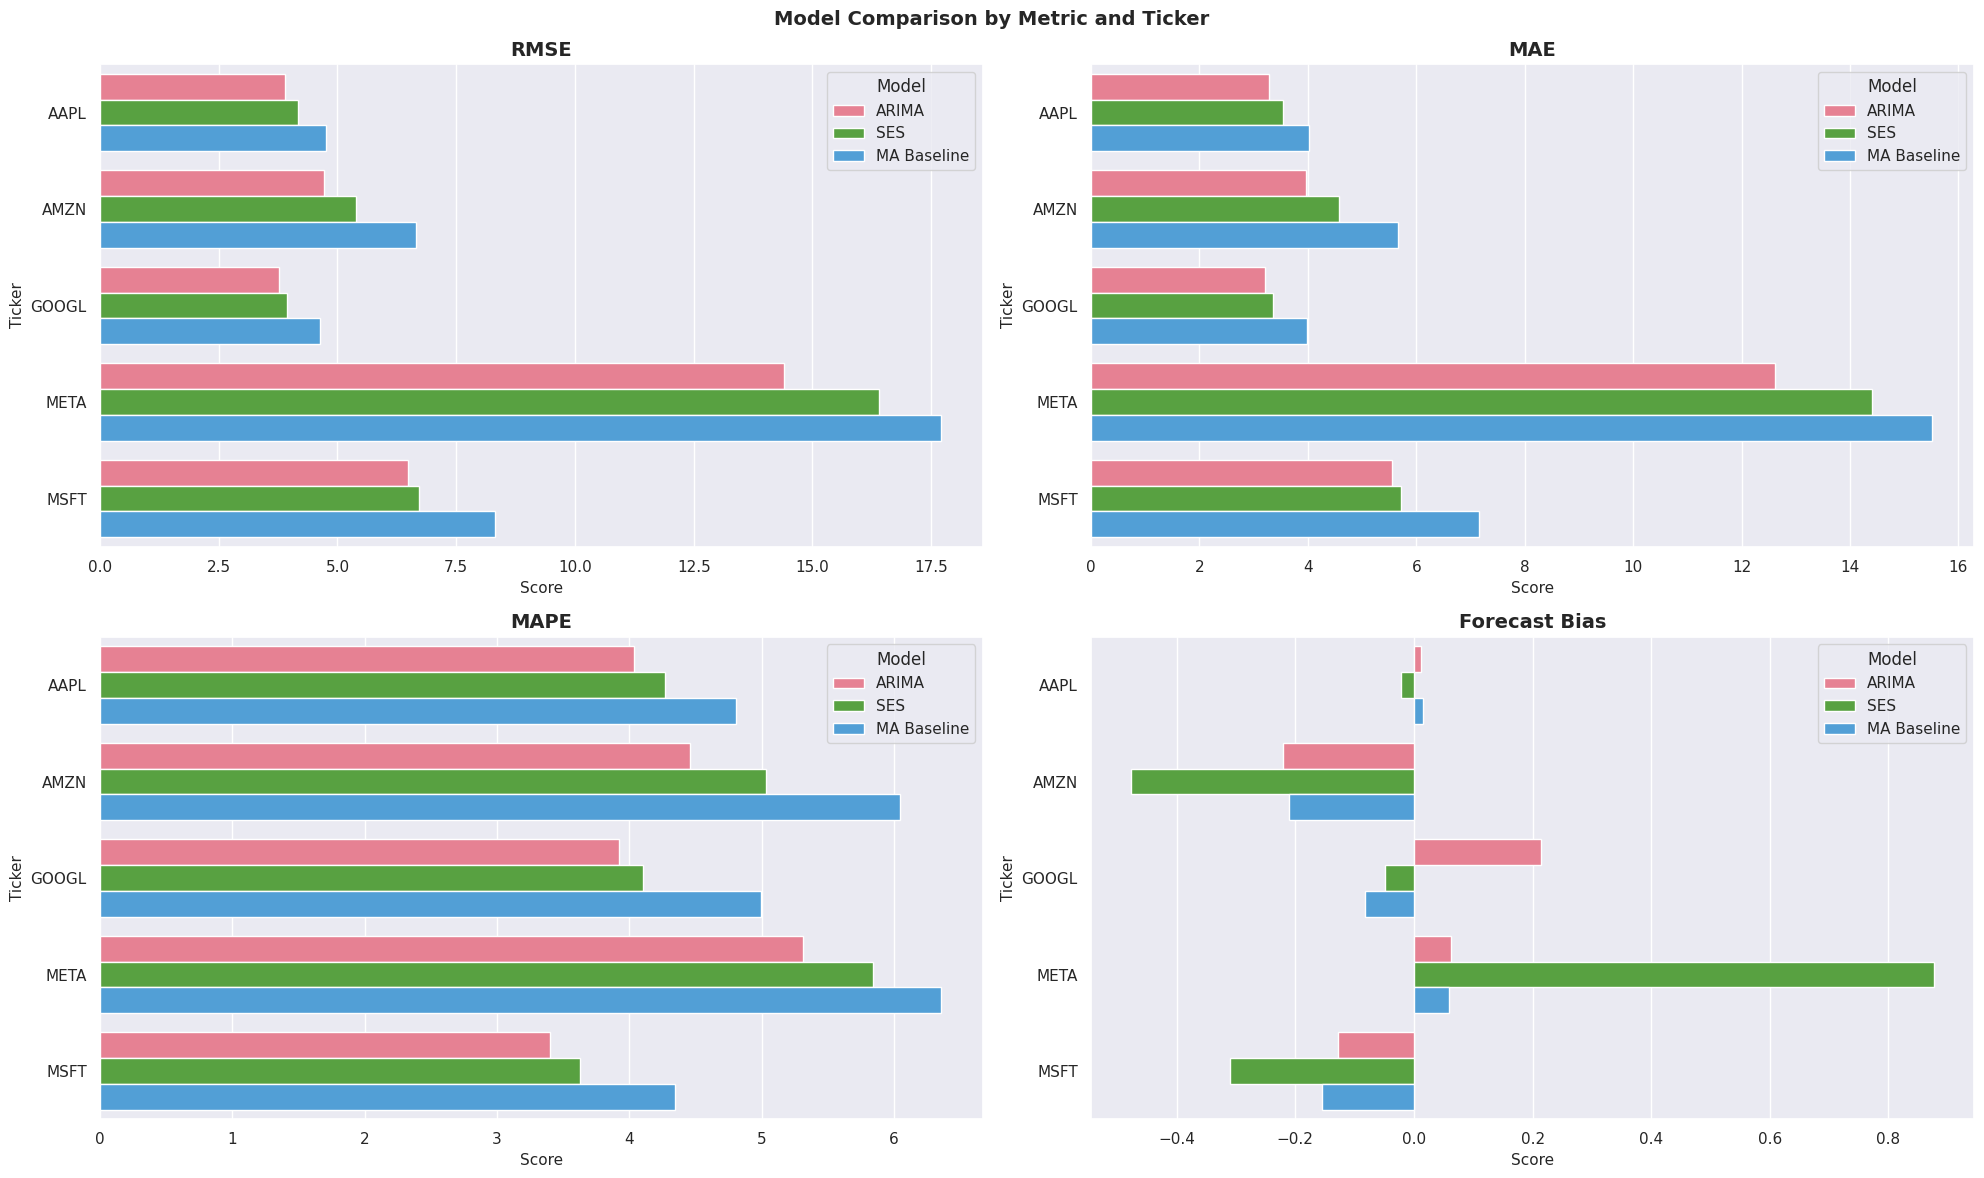

In [180]:
metrics = ["RMSE", "MAE", "MAPE", "Forecast Bias"]
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=results,
        y="Ticker",
        x=metric,
        hue="Model",
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("Score")
    ax.legend(title="Model", bbox_to_anchor=(1, 1))

plt.suptitle("Model Comparison by Metric and Ticker", fontsize=14)
plt.tight_layout()
plt.show()

* ARIMA (seen in pink) & LGBM (green) compete very closely as the top 2 performing models across the board of metrics. 
* Their RMSEs may be 0.002 or 0.2 apart.
* Forecast Bias: 3/5 times ARIMA is less biased than LGBM. 
    * Interestingly LGBM really captures the most volatile asset with barely any forecast bias on META.

4/5 times ARIMA performs better and the performance follows this pattern: 
1. ARIMA
2. LGBM
3. SES
4. MA Baseline

(Except for GOOGL where LGBM performs better.)

### 4.2 Forecasting

With our strong performing ARIMA and LGB models, we can take a look at how the stock prices will be over the next month with both for linear forecast (ARIMA) and non-linear (LGB). 

#### 4.2.1 Next Month's Forecast Plot

(Since LGB was constructed on difference-level per fold, it will need to be reconstructed upon plotting)

In [ ]:
# removing leading NaN from computed differences
df_diff = df_close.diff().dropna()
df_close = df_close.loc[df_diff.index]

fig, axes = plt.subplots(len(tickers), 2, figsize=(20, 4 * len(tickers)))
if len(tickers) == 1:
    axes = [axes]

for i, ticker in enumerate(tickers):
    # showing last year for context
    history = df_close[ticker].values[-252:]
    anchor = df_close[ticker].iloc[-1]

    history_dates = df_close.index[-252:]
    last_date = history_dates[-1]
    future_dates = pd.bdate_range(start=last_date, periods=22)[1:]

    # Use stored ARIMA model (trained on all data)
    saved_arima = final_models[ticker]["arima"]
    arima_preds = anchor + np.cumsum(saved_arima.forecast(steps=21))

    ax = axes[i][0]
    ax.plot(
        history_dates, history, color=logo_palette[ticker], linewidth=1, label="History"
    )
    ax.plot(
        future_dates,
        arima_preds,
        color="purple",
        linewidth=1.5,
        linestyle="--",
        label="Forecast",
    )
    ax.axvline(x=last_date, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ticker}: ARIMA Forecast")
    ax.legend(fontsize=8)

    # Use stored LGBM model (trained on all data)
    saved_lgbm = final_models[ticker]["lgbm"]
    x_input = create_more_features(forecast_df[ticker]["diff"][-21:])
    lgbm_diff_preds = saved_lgbm.predict(x_input)[0]
    lgbm_preds = anchor + np.cumsum(lgbm_diff_preds)

    ax = axes[i][1]
    ax.plot(
        history_dates, history, color=logo_palette[ticker], linewidth=1, label="History"
    )
    ax.plot(
        future_dates,
        lgbm_preds,
        color="purple",
        linewidth=1.5,
        linestyle="--",
        label="Forecast",
    )
    ax.axvline(x=last_date, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ticker}: LGBM Forecast")
    ax.legend(fontsize=8)

plt.suptitle(
    "ARIMA vs LGBM: Next Month Pricing Forecast", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

Over the next month, movement of stock prices are relatively stable with no steep downward or upward momentum.

#### 4.2.2 Next Day Closing Prices

Using the yfinance data we can check the actual close prices on the next day, March 23, and compare how our predictions did.

In [182]:
next_day_preds = {}

for ticker in tickers:
    anchor = df_close[ticker].iloc[-1]

    arima_model_fit = final_models[ticker]["arima"]
    next_day_diff = arima_model_fit.forecast(steps=1)[0]
    next_day_preds[ticker] = anchor + next_day_diff

next_day_date = pd.bdate_range(start=df_close.index[-1], periods=2)[-1]

pred = pd.Series(next_day_preds, name="Predicted Close").round(2)
actual = get_actual_close(tickers).rename("Actual Close (2026-03-23)")
difference = (pred - actual).rename("Difference").round(2)
pct_diff = ((pred - actual) / actual * 100).round(2).rename("% Diff")

df_compare = pd.concat([pred, actual, difference, pct_diff], axis=1)

df_compare

,Predicted Close,Actual Close (2026-03-23),Difference,% Diff
AAPL,248.02,251.490005,-3.47,-1.38
MSFT,382.58,383.000000,-0.42,-0.11
AMZN,205.57,210.139999,-4.57,-2.17
GOOGL,301.16,302.059998,-0.90,-0.30
META,594.43,604.059998,-9.63,-1.59


Predicted close prices on March 23 are -0.30% and no more than -2.17% off.

## ⏱️ 5. Survival Analysis

> Using survival analysis methods, train models that are capable of predicting time to event (in this case event is ≥5% daily increase in stock price). Note: the model should be the same for all stocks. Evaluate its performance on each stock independently.

**📌 Event: ≥5% daily increase in stock price**


### Survival Data

For survival analysis we can engineer features for this purpose. 

Particularly we need:
1. `durations` - target variable: number of days until event occurred 
2. `event_observed` (1 or 0): 1 if daily return is greater than or equal to 5%, else 0.

And make use of covariate features:
1. `avg_volatility`: volatility series pulled from the df, avg_vol computed over each window. Does volatility affect how quickly a 5% return happens?

Note that META is left-censored / truncated with a later starting date compared to the other stocks. However since each ticker gets its own independent duration and is observed separately this is not an issue.

In [183]:
rows = []

for ticker in tickers:
    returns = df["Return"][ticker].dropna().reset_index(drop=True)
    volatility = df["Volatility"][ticker].dropna().reset_index(drop=True)

    # Event threshold in log-return terms: ln(1.05)
    # 5% return inversed from log space
    event = (returns >= np.log(1.05)).astype(int)
    last_event_idx = 0

    for i in range(len(returns)):
        if event[i] == 1:
            duration = i - last_event_idx
            avg_vol = volatility[last_event_idx : i + 1].mean()

            rows.append(
                {
                    "ticker": ticker,
                    "duration": duration,
                    "event_observed": 1,
                    "avg_volatility": avg_vol,
                }
            )

            last_event_idx = i + 1

    if last_event_idx < len(returns):
        duration = len(returns) - last_event_idx
        avg_vol = volatility[last_event_idx:].mean()

        rows.append(
            {
                "ticker": ticker,
                "duration": duration,
                "event_observed": 0,
                "avg_volatility": avg_vol,
            }
        )

survival_df = pd.DataFrame(rows)
survival_df.head()

,ticker,duration,event_observed,avg_volatility
0,AAPL,73,1,0.272394
1,AAPL,12,1,0.443598
2,AAPL,315,1,0.232784
3,AAPL,42,1,0.302595
4,AAPL,72,1,0.243686


### Kaplan-Meier Curves

Kaplan Meier to visualize time-to-event

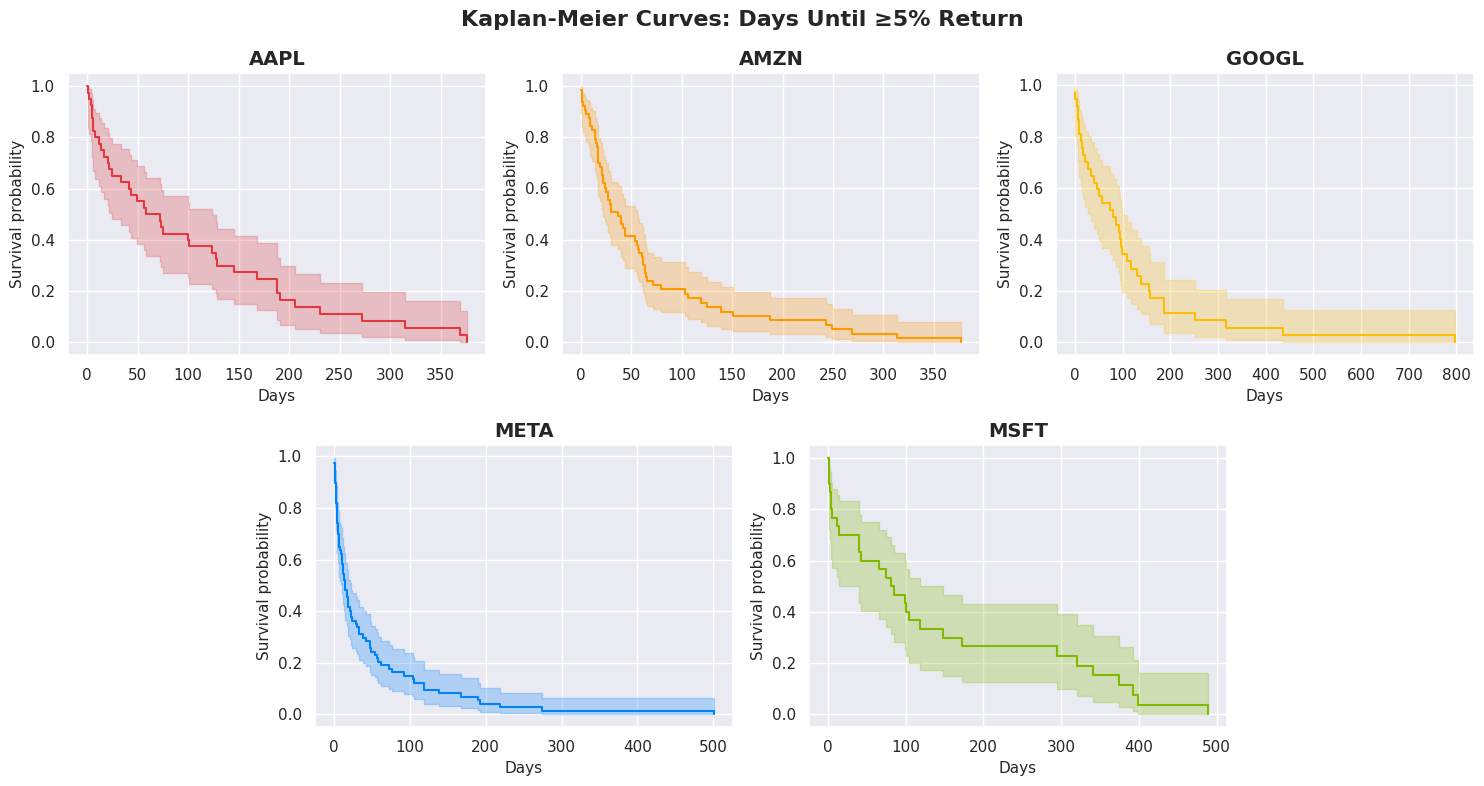

In [185]:
mosaic = """AABBCC
            .DDEE."""

fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(15, 8))


for ax_key, ticker in zip(
    sorted(ax_dict.keys()), sorted(survival_df["ticker"].unique())
):
    subset = survival_df[survival_df["ticker"] == ticker]

    kmf = KaplanMeierFitter()
    kmf.fit(subset["duration"], subset["event_observed"], label=ticker)
    kmf.plot_survival_function(
        ax=ax_dict[ax_key], ci_show=True, color=logo_palette[ticker]
    )

    ax_dict[ax_key].set_title(ticker)
    ax_dict[ax_key].set_xlabel("Days")
    ax_dict[ax_key].set_ylabel("Survival probability")
    ax_dict[ax_key].legend().remove()

fig.suptitle("Kaplan-Meier Curves: Days Until ≥5% Return")
plt.tight_layout()
plt.show()

* META survival curve drops almost vertically and 5% increase happens almost constantly. This matches its high volatility seen throughout the notebook. Its confidence bands are narrow and remain low suggesting that 5% moves are in fact frequent.
* Wider confidence bands for other assets indicate more variability. 
* Survival curves drop most slowly for MSFT with almost lateral movement and no event time observed over a long period of days.

### Log-Rank Test

Determining if the survival curves seen above **differ significantly** between two or more groups

In [186]:
logrank_rows = []

for ticker_a, ticker_b in combinations(tickers, 2):
    a = survival_df[survival_df["ticker"] == ticker_a]
    b = survival_df[survival_df["ticker"] == ticker_b]

    results = logrank_test(
        a["duration"],
        b["duration"],
        event_observed_A=a["event_observed"],
        event_observed_B=b["event_observed"],
    )

    logrank_rows.append(
        {
            "ticker_a": ticker_a,
            "ticker_b": ticker_b,
            "p_value": round(results.p_value, 4),
        }
    )

logrank_df = pd.DataFrame(logrank_rows)

logrank_df_sorted = logrank_df.sort_values("p_value").reset_index(drop=True)

logrank_df_sorted.style.map(
    lambda val: f"color: {logo_palette.get(val, '')}", subset=["ticker_a", "ticker_b"]
).map(
    lambda val: "color: green; font-weight: 500" if val < 0.05 else "",
    subset=["p_value"],
).format(
    {"p_value": "{:.4f}"}
)

,ticker_a,ticker_b,p_value
0,MSFT,META,0.0009
1,AAPL,META,0.0014
2,GOOGL,META,0.0017
3,MSFT,AMZN,0.0049
4,AMZN,META,0.0412
5,AMZN,GOOGL,0.0501
6,AAPL,AMZN,0.0815
7,AAPL,MSFT,0.2110
8,MSFT,GOOGL,0.5278
9,AAPL,GOOGL,0.9693


META is most different compared to the other assets - always having statistically different survival curves with p-values < 0.05

### Cox Proportional Hazards Model

Estimate effects of covariates (Volatility) without making strong assumptions using a semi-parametric model, perfect for our complex and right-tailed financial data

In [187]:
survival_results = []

for ticker in tickers:
    ticker_df = (
        survival_df[survival_df["ticker"] == ticker][
            ["duration", "event_observed", "avg_volatility"]
        ]
        .dropna()
        .reset_index(drop=True)
    )

    # Standardizing volatility
    scaler = StandardScaler()
    ticker_df["avg_volatility_scaled"] = scaler.fit_transform(
        ticker_df[["avg_volatility"]]
    )

    cox_df = ticker_df[["duration", "event_observed", "avg_volatility_scaled"]].copy()

    cph = CoxPHFitter()
    cph.fit(cox_df, duration_col="duration", event_col="event_observed")

    ci = cph.concordance_index_

    times = np.percentile(ticker_df["duration"], np.linspace(5, 95, 50))
    brier_scores = []

    for t in times:
        surv_func = cph.predict_survival_function(cox_df, times=[t])
        s_t = surv_func.loc[t].values

        event_by_t = (ticker_df["duration"].values <= t) & (
            ticker_df["event_observed"].values == 1
        )

        bs = np.mean((s_t - (~event_by_t).astype(float)) ** 2)
        brier_scores.append(bs)

    ibs = np.nanmean(brier_scores)

    # Calculating median survival time when S(t) = 0.5 or when event has 50% median chance to happen
    avg_volatility = cox_df["avg_volatility_scaled"].mean()
    avg_obs = pd.DataFrame({"avg_volatility_scaled": [avg_volatility]})
    surv_func = cph.predict_survival_function(avg_obs)

    past_median = surv_func.values.flatten() < 0.5
    time_to_event = (
        round(surv_func.index[past_median.argmax()].item(), 1)
        if past_median.any()
        else np.inf
    )

    survival_results.append(
        {
            "ticker": ticker,
            "time_to_event": time_to_event,
            "concordance_index": round(ci, 4),
            "brier_score": round(ibs, 4),
        }
    )

survival_results_df = pd.DataFrame(survival_results)
survival_results_df.sort_values("concordance_index", ascending=False).reset_index(
    drop=True
)

,ticker,time_to_event,concordance_index,brier_score
0,MSFT,81.0,0.8487,0.1299
1,GOOGL,79.0,0.8225,0.1085
2,AAPL,49.0,0.8057,0.1187
3,AMZN,40.0,0.7690,0.1281
4,META,17.0,0.6918,0.1636


* Time to Event: Amount of days until the next ≥5% simple return, given current volatility regime
* Concordance Index: how well volatility ranks the risk ordering / can the model rank outcomes correctly?
* Brier Score: calibration of predicted survival probabilities / are predicted probabilities accurate?

Key Findings:

* Concordance Indices are up to the ~0.80 range which are closer to 1.0 indicating strong ranking performance. The Cox model can effectively distinguish between shorter and longer time for return increase events. 
* Stocks with higher volatilty tend to experience 5% increase in returns sooner as seen with META (only 17 days until event)
* Volatility being the covariate is a good high index predictor of event timing for stable stocks like MSFT, GOOGL, and AAPL having the strongest signals and C-indices. 

## 🥇 6. Ranking

> Build ranking model that is capable of ranking given stocks in descending order in terms of possible daily gains from each stock.

> Ranking Models <br> We construct a relative ranking of stocks at each time step based on predicted returns or risk-adjusted metrics. This supports portfolio allocation and decision-making strategies that prioritize the most promising assets at any given moment.


* **🎯 Objective: Rank the 5 stocks based on possible daily gains from each stock**
* Model: LGB with lambdarank 
* Method: Pairwise
    * Ranking assets through pair combinations and directly comparing them to one another in order for a full implicit list. Given that we only have 5 assets this is a moderate number that we can create pairs with.   
* Evaluation: NDCG
    * NDCG is a metric that can emphasize ranking higher items closer to the top. Errors at the higher rank are penalized more. 

### 6.0 Data Preparation for Ranking

For Ranking, data needs to be organized as Query-Item pairs and have a Relevance Label:
* Query ID: Date
* Item ID: Ticker
* Relevance label: Indicate based on returns how relevant it is for the query

Features that describe the query-item pairs can assist the model: 
* Lag Returns
* Lag Volume
* Volatility


⚠️ For LGB with lambdarank "label should be int type, and larger number represents the higher relevance (e.g. 0:bad, 1:fair, 2:good, 3:perfect)". This is inverted from our supposed results where 1 is better and 5 is worst. Ranking will be inversed for the model training but reverted back for display.

* For model building: Lower is worse [0 - 4 worst to best]
* For display results: Lower is better [5 - 1 worst to best]

🗒️ Truncating to **common start date**: The objective is to rank a common start date so a common start date, where all 5 stocks exist will be used to train the data. We will not train on data where only 4 stocks existed.

In [188]:
rank_df = df.copy()
rank_df = rank_df.stack(level="Ticker", future_stack=True).reset_index()
rank_df = rank_df.dropna(subset=["Return", "Volatility"])

# Shift forward to tomorrow's return: value to predict
rank_df["ret_tomo"] = rank_df.groupby("Ticker")["Return"].shift(-1)
rank_df = rank_df.dropna(subset=["ret_tomo"])

# Truncate to common start from where all 5 stocks have data
common_start = rank_df.groupby("Ticker")["Date"].min().max()
rank_df = rank_df[rank_df["Date"] >= common_start]

# Relevance for display descending where 1 is best and 5 is worst (goes from 5-1)
rank_df["Ranking"] = (
    rank_df.groupby("Date")["ret_tomo"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Relevance for Model Learning where higher numbers = better ranking (goes 0-4)
rank_df["rank_for_model"] = 5 - rank_df["Ranking"]

Adding more features:
- Week-long return lags (trading days shifted back 1-5)
- Week-long volatility lags (trading days shifted back 1-5)
- Rolling return means
- Rolling volatility means

In [189]:
for lag in range(1, 6):
    rank_df[f"ret_lag{lag}"] = rank_df.groupby("Ticker")["Return"].shift(lag)

for lag in range(1, 6):
    rank_df[f"vol_lag{lag}"] = rank_df.groupby("Ticker")["Volatility"].shift(lag)

rank_df["ret_roll3"] = rank_df.groupby("Ticker")["Return"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
rank_df["ret_roll5"] = rank_df.groupby("Ticker")["Return"].transform(
    lambda x: x.shift(1).rolling(5).mean()
)

rank_df["vol_roll3"] = rank_df.groupby("Ticker")["Volatility"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
rank_df["vol_roll5"] = rank_df.groupby("Ticker")["Volatility"].transform(
    lambda x: x.shift(1).rolling(5).mean()
)

feature_cols = [
    "ret_lag1",
    "ret_lag2",
    "ret_lag3",
    "ret_lag4",
    "ret_lag5",
    "vol_lag1",
    "vol_lag2",
    "vol_lag3",
    "vol_lag4",
    "vol_lag5",
    "ret_roll3",
    "ret_roll5",
    "vol_roll3",
    "vol_roll5",
]

rank_df = rank_df.dropna(subset=feature_cols)

* 80/20 train-test split by cutoff date

In [190]:
sorted_dates = sorted(rank_df["Date"].unique())
cutoff = sorted_dates[int(len(sorted_dates) * 0.8)]

train = rank_df[rank_df["Date"] <= cutoff].sort_values("Date")
test = rank_df[rank_df["Date"] > cutoff].sort_values("Date")

train_data = lgb.Dataset(
    train[feature_cols],
    label=train["rank_for_model"],
    group=train.groupby("Date", sort=True).size().tolist(),
)
test_data = lgb.Dataset(
    test[feature_cols],
    label=test["rank_for_model"],
    group=test.groupby("Date").size().tolist(),
)

train_df = train[["Date", "Ticker", "rank_for_model"] + feature_cols].copy()

### 6.1 Ranking Model

* Measure ranking quality via NDCG on test set by date

In [213]:
params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5],
    "verbose": -1,
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(50)],
    valid_sets=[test_data],
)

test = test.copy()
test["Score"] = model.predict(test[feature_cols])
test["Score"] = test["Score"].fillna(-np.inf)
test["Predicted Rank"] = (
    test.groupby("Date")["Score"].rank(ascending=False, method="first").astype(int)
)
test = test.sort_values(["Date", "Predicted Rank"], ascending=[True, True])


def compute_ndcg(group, k=5):
    y_true = group["rank_for_model"].values.reshape(1, -1)
    y_score = group["Score"].values.reshape(1, -1)
    return ndcg_score(y_true, y_score, k=k)


ndcg_per_date = (
    test.groupby("Date").apply(compute_ndcg, include_groups=False).rename("NDCG")
)
test = test.join(ndcg_per_date, on="Date")

test[["Date", "Ticker", "Predicted Rank", "Ranking", "Score", "NDCG"]].sort_values(
    ["Date", "Predicted Rank"]
).tail(30)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[3]	valid_0's ndcg@5: 0.72302


ValueError: columns overlap but no suffix specified: Index(['NDCG'], dtype='object')

### 6.2 Ranking Results

Average ranking of all time

In [192]:
# Compute average predicted and actual ranking per ticker
avg_ranking = (
    test.groupby("Ticker")
    .agg(
        Avg_Predicted_Rank=("Predicted Rank", "mean"),
        Avg_Actual_Rank=("Ranking", "mean"),
        Avg_NDCG=("NDCG", "mean"),
    )
    .reset_index()
)

# Convert to 1-5
avg_ranking["All Time Pred Rank"] = (
    avg_ranking["Avg_Predicted_Rank"].rank(method="min").astype(int)
)
avg_ranking["All Time Actual Rank"] = (
    avg_ranking["Avg_Actual_Rank"].rank(method="min").astype(int)
)

avg_ranking = avg_ranking.sort_values("All Time Pred Rank").reset_index(drop=True)

print("Average NDCG:", avg_ranking["Avg_NDCG"].mean())
avg_ranking[["Ticker", "All Time Pred Rank", "All Time Actual Rank"]]

Average NDCG: 0.8072568521995482


,Ticker,All Time Pred Rank,All Time Actual Rank
0,META,1,3
1,AMZN,2,5
2,GOOGL,3,1
3,AAPL,4,2
4,MSFT,5,4


Average Ranking per Year

In [ ]:
test["Year"] = test["Date"].dt.year

avg_ranking_yearly = (
    test.groupby(["Year", "Ticker"])
    .agg(
        Avg_Predicted_Rank=("Predicted Rank", "mean"),
        Avg_Actual_Rank=("Ranking", "mean"),
        Avg_NDCG=("NDCG", "mean"),
    )
    .reset_index()
)

avg_ranking_yearly["Yearly Pred Rank"] = (
    avg_ranking_yearly.groupby("Year")["Avg_Predicted_Rank"]
    .rank(method="first")
    .astype(int)
)
avg_ranking_yearly["Yearly Actual Rank"] = (
    avg_ranking_yearly.groupby("Year")["Avg_Actual_Rank"]
    .rank(method="first")
    .astype(int)
)

# multi-index per year
avg_ranking_yearly = avg_ranking_yearly.sort_values(
    ["Year", "Yearly Pred Rank"]
).set_index(["Year", "Ticker"])

print("Average NDCG per Year per Ticker")
print(test.groupby("Year")["NDCG"].mean().round(4).to_string())

avg_ranking_yearly[["Yearly Pred Rank", "Yearly Actual Rank"]]

Average NDCG per Year per Ticker
Year
2023    0.8038
2024    0.8152
2025    0.8012
2026    0.8070


Yearly Pred Rank  Yearly Actual Rank
Year Ticker                                      
2023 META                   1                   1
     AMZN                   2                   5
     MSFT                   3                   2
     GOOGL                  4                   4
     AAPL                   5                   3
2024 META                   1                   2
     GOOGL                  2                   4
     AAPL                   3                   1
     AMZN                   4                   3
     MSFT                   5                   5
2025 GOOGL                  1                   1
     AMZN                   2                   4
     META                   3                   5
     AAPL                   4                   3
     MSFT                   5                   2
2026 AMZN                   1                   2
     META                   2                   4
     MSFT                   3                   3
     GOOGL                  4                   1
     AAPL                   5                   5

## 7. Conclusion

Suggestions for Further Research:
- Alternative source from Yahoo Finance to a more well-known modern source for data
- Take into account the turbulence of the markets in recent times
- Forecasting: Attempt ensembling for forecasting for even more robust modelling and predictions.
- Ranking: Explore different methods (listwise) and different models, add features to help model building

### Key Findings:
1. Time-Series Forecasting
    - Out of 4 different types of models, ARIMA performs best 4/5 times and is less biased 3/5 times than the 2nd best performer, LGBM.
    - Predicted close prices on the next day March 23 are -0.30% and no more than -2.17% off.
2. Survival Analysis
    - The Cox Proportional Hazards model can effectively distinguish between shorter and longer time for 5% return increase events.  
    - Its Concordance Indices are up to the ~0.80 range which are closer to 1.0 indicating strong ranking performance. 
    - Stocks with higher volatilty tend to experience 5% increase in returns sooner as seen with META (only 17 days until event)
    - Event timing for stable stocks like MSFT, GOOGL, and AAPL having the strongest signals and C-indices. 
3. Ranking
    - NDCG per year per ticker sits at around the ~0.80 mark
    - LGB with lambdarank pairwise shows good ranking potential and some room for improvement
    - Ranking of the 5 stocks so far this year is as follows:
    1. AMZN
    2. META
    3. MSFT
    4. GOOGL
    5. AAPL